# Paragliding Weather Forecast

A notebook to predict flying conditions at a given paragliding site using the [Open-Meteo Forecast API](https://open-meteo.com/en/docs).

Site metadata (coordinates, favourable wind directions, etc.) is loaded from `sites.json`.

---

## Open-Meteo Parameters

### Hourly Surface Variables

**Wind (multiple heights above ground)**

| Parameter | Description |
|---|---|
| `wind_speed_10m`, `wind_speed_80m`, `wind_speed_120m`, `wind_speed_180m` | Wind speed at 10 / 80 / 120 / 180 m AGL |
| `wind_direction_10m`, `wind_direction_80m`, `wind_direction_120m`, `wind_direction_180m` | Wind direction at 10 / 80 / 120 / 180 m AGL |
| `wind_gusts_10m` | Max gust in the preceding hour at 10 m |

**Temperature & Humidity (multiple heights)**

| Parameter | Description |
|---|---|
| `temperature_2m`, `temperature_80m`, `temperature_120m`, `temperature_180m` | Air temperature at 2 / 80 / 120 / 180 m AGL |
| `dew_point_2m` | Dew point at 2 m (moisture / cloud base estimate) |
| `apparent_temperature` | Feels-like temperature |
| `relative_humidity_2m` | Relative humidity at 2 m |

**Pressure & Thermodynamics**

| Parameter | Description |
|---|---|
| `pressure_msl` | Atmospheric pressure reduced to mean sea level |
| `surface_pressure` | Actual surface pressure |
| `cape` | Convective Available Potential Energy — key indicator of instability and thermal strength |
| `freezing_level_height` | Altitude of 0 °C isotherm (icing level, snowball altitude) |

**Cloud Cover (layered)**

| Parameter | Description |
|---|---|
| `cloud_cover` | Total cloud cover (%) |
| `cloud_cover_low` | Low cloud / fog (< 3 km) |
| `cloud_cover_mid` | Mid cloud (3–8 km) |
| `cloud_cover_high` | High cloud (> 8 km) |
| `visibility` | Horizontal visibility in metres |

**Precipitation**

| Parameter | Description |
|---|---|
| `precipitation` | Total precipitation (rain + showers + snow) |
| `rain` | Large-scale rain |
| `showers` | Convective showers |
| `snowfall` | Snowfall in cm |
| `precipitation_probability` | Probability of > 0.1 mm (%) |
| `weather_code` | WMO weather interpretation code |

**Solar Radiation** *(thermal trigger timing)*

| Parameter | Description |
|---|---|
| `shortwave_radiation` | Global horizontal irradiance (W/m²) |
| `direct_radiation` | Direct horizontal irradiance |
| `direct_normal_irradiance` | Direct normal irradiance (DNI) |
| `diffuse_radiation` | Diffuse sky radiation |
| `is_day` | 1 = daylight, 0 = night |

---

### Pressure Level Variables (Skew-T / Sounding)

Request levels: **1000, 975, 950, 925, 900, 850, 800, 700, 600, 500 hPa**
(covers roughly 110 m to 5 600 m ASL — the full XC paragliding envelope)

| Parameter (per level) | Description |
|---|---|
| `temperature_{level}hPa` | Temperature profile — lapse rate, inversions |
| `dew_point_{level}hPa` | Moisture profile — cloud base, humidity |
| `relative_humidity_{level}hPa` | Relative humidity at pressure level |
| `wind_speed_{level}hPa` | Wind speed — shear analysis |
| `wind_direction_{level}hPa` | Wind direction at pressure level |
| `geopotential_height_{level}hPa` | Actual altitude (m ASL) of each pressure level |
| `cloud_cover_{level}hPa` | Cloud cover fraction at pressure level |

---

### Daily Summary Variables

| Parameter | Description |
|---|---|
| `temperature_2m_max`, `temperature_2m_min` | Daily temperature range |
| `wind_speed_10m_max`, `wind_gusts_10m_max` | Daily max wind speed and gusts |
| `wind_direction_10m_dominant` | Dominant wind direction for the day |
| `precipitation_sum`, `rain_sum`, `showers_sum` | Daily precipitation totals |
| `precipitation_probability_max` | Peak precipitation probability |
| `weather_code` | Most severe WMO code of the day |
| `sunrise`, `sunset` | Sun rise / set times |
| `daylight_duration`, `sunshine_duration` | Seconds of daylight and sunshine |
| `uv_index_max` | Daily UV index peak |
| `shortwave_radiation_sum` | Total solar radiation (MJ/m²) |

---

## Analysis Enabled by These Parameters

| Analysis | Variables Used |
|---|---|
| Launch window (wind vs site aspect) | `wind_direction_*`, `wind_speed_*` at all surface levels |
| Thermal strength & trigger time | `cape`, `shortwave_radiation`, `temperature_2m`, pressure-level lapse rate |
| Skew-T / sounding plot | Pressure level temp, dew point, wind, geopotential |
| Overdevelopment / Cu-nim risk | `cape`, `cloud_cover_*`, `showers`, `weather_code` |
| Inversion layer detection | Temperature profile from pressure levels |
| Flying altitude ceiling | `cloud_cover_mid/high`, `freezing_level_height` |
| Daily go/no-go summary | Daily vars + `weather_code` |

In [12]:
# Install dependencies with uv
import subprocess
subprocess.run(
    ["uv", "pip", "install", "openmeteo-requests", "requests-cache", "retry-requests", "numpy", "pandas", "matplotlib", "metpy"],
    check=True,
)


Audited 7 packages in 5ms


CompletedProcess(args=['uv', 'pip', 'install', 'openmeteo-requests', 'requests-cache', 'retry-requests', 'numpy', 'pandas', 'matplotlib', 'metpy'], returncode=0)

# Fetch forecast data

In [13]:
# import openmeteo_requests
# import json
# import pandas as pd
# import requests_cache
# from retry_requests import retry
# from pathlib import Path
# from datetime import datetime

# # ── Model selection ────────────────────────────────────────────────────────────
# # Options (Europe):
# #   "best_match"      – Open-Meteo seamless blend (default)
# #   "ecmwf_ifs025"    – ECMWF IFS 0.25°, global, 6-hourly analysis
# #   "icon_eu"         – DWD ICON-EU 0.0625°, best resolution for Europe
# #   "icon_d2"         – DWD ICON-D2 0.02°, Germany/Alps/BeNeLux only, 2 km
# #   "arome_france"    – Météo-France AROME 0.025°, France + neighbours
# #   "gfs_seamless"    – NOAA GFS, global
# MODEL = "ecmwf_ifs025"

# # ── Load site ──────────────────────────────────────────────────────────────────
# with open("sites.json") as f:
#     sites = json.load(f)

# site = sites[0]  # change index to select a different site
# lat, lon = site["coordinates"]
# print(f"Fetching forecast for: {site['name']}  ({lat}, {lon})")
# print(f"Model: {MODEL}")

# # ── Setup client with 1-hour cache and auto-retry ─────────────────────────────
# cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
# retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
# openmeteo = openmeteo_requests.Client(session=retry_session)

# # ── Parameter lists ────────────────────────────────────────────────────────────
# PRESSURE_LEVELS = [1000, 975, 950, 925, 900, 850, 800, 700, 600, 500]
# PRESSURE_VARS   = ["temperature", "dew_point", "relative_humidity",
#                    "wind_speed", "wind_direction", "geopotential_height", "cloud_cover"]

# hourly_params = [
#     # Surface wind
#     "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m",
#     "wind_direction_10m", "wind_direction_80m", "wind_direction_120m", "wind_direction_180m",
#     "wind_gusts_10m",
#     # Temperature / humidity
#     "temperature_2m", "temperature_80m", "temperature_120m", "temperature_180m",
#     "dew_point_2m", "apparent_temperature", "relative_humidity_2m",
#     # Pressure & thermodynamics
#     "pressure_msl", "surface_pressure",
#     "cape", "lifted_index", "convective_inhibition",
#     "freezing_level_height", "boundary_layer_height",
#     # Cloud cover
#     "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
#     "visibility",
#     # Precipitation
#     "precipitation", "rain", "showers", "snowfall", "precipitation_probability",
#     "weather_code",
#     # Solar radiation
#     "shortwave_radiation", "direct_radiation", "direct_normal_irradiance",
#     "diffuse_radiation", "is_day",
#     # Pressure-level sounding variables (for Skew-T)
#     *[f"{var}_{lvl}hPa" for lvl in PRESSURE_LEVELS for var in PRESSURE_VARS],
# ]

# daily_params = [
#     "temperature_2m_max", "temperature_2m_min",
#     "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant",
#     "precipitation_sum", "rain_sum", "showers_sum", "precipitation_probability_max",
#     "weather_code",
#     "sunrise", "sunset", "daylight_duration", "sunshine_duration",
#     "uv_index_max", "shortwave_radiation_sum",
# ]

# # ── Fetch ──────────────────────────────────────────────────────────────────────
# responses = openmeteo.weather_api(
#     "https://api.open-meteo.com/v1/forecast",
#     params={
#         "latitude": lat,
#         "longitude": lon,
#         "hourly": hourly_params,
#         "daily": daily_params,
#         "models": MODEL,
#         "wind_speed_unit": "kmh",
#         "forecast_days": 5,
#         "timezone": "auto",
#     },
# )

# response = responses[0]
# timezone = response.Timezone()
# if isinstance(timezone, bytes):
#     timezone = timezone.decode()
# timezone_abbr = response.TimezoneAbbreviation()
# if isinstance(timezone_abbr, bytes):
#     timezone_abbr = timezone_abbr.decode()

# print(f"Coordinates : {response.Latitude():.4f}°N  {response.Longitude():.4f}°E")
# print(f"Elevation   : {response.Elevation()} m asl")
# print(f"Timezone    : {timezone} ({timezone_abbr})")

# # ── Build hourly DataFrame ─────────────────────────────────────────────────────
# hourly = response.Hourly()
# hourly_df = pd.DataFrame({
#     "time": pd.date_range(
#         start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
#         end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
#         freq=pd.Timedelta(seconds=hourly.Interval()),
#         inclusive="left",
#     ),
#     **{name: hourly.Variables(i).ValuesAsNumpy() for i, name in enumerate(hourly_params)},
# })

# # ── Filter to flying window (10:00–16:00 local time) ──────────────────────────
# local_hour = hourly_df["time"].dt.tz_convert(timezone).dt.hour
# hourly_df = hourly_df[local_hour.between(10, 16)].reset_index(drop=True)

# # ── Build daily DataFrame ──────────────────────────────────────────────────────
# daily = response.Daily()
# daily_df = pd.DataFrame({
#     "time": pd.date_range(
#         start=pd.to_datetime(daily.Time(), unit="s", utc=True),
#         end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
#         freq=pd.Timedelta(seconds=daily.Interval()),
#         inclusive="left",
#     ),
#     **{name: daily.Variables(i).ValuesAsNumpy() for i, name in enumerate(daily_params)},
# })

# print(f"\nHourly : {len(hourly_df)} timesteps (10:00–16:00 local)")
# print(f"Daily  : {len(daily_df)} days")

# # ── Save to file ───────────────────────────────────────────────────────────────
# site_slug = site["name"].lower().replace(" ", "_")
# out_dir = Path("data") / site_slug
# out_dir.mkdir(parents=True, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# out_file = out_dir / f"{site_slug}_{timestamp}.json"

# with open(out_file, "w") as f:
#     json.dump(
#         {
#             "site": site,
#             "meta": {
#                 "latitude": response.Latitude(),
#                 "longitude": response.Longitude(),
#                 "elevation": response.Elevation(),
#                 "timezone": timezone,
#                 "utc_offset_seconds": response.UtcOffsetSeconds(),
#                 "model": MODEL,
#             },
#             "hourly": json.loads(hourly_df.to_json(orient="records", date_format="iso")),
#             "daily":  json.loads(daily_df.to_json(orient="records", date_format="iso")),
#         },
#         f,
#         indent=2,
#     )

# print(f"Saved → {out_file}")


In [14]:
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import matplotlib.patches as mpatches
# import numpy as np

# # ── Prepare local-time columns ─────────────────────────────────────────────────
# df = hourly_df.copy()
# df["local_time"] = df["time"].dt.tz_convert(timezone)
# df["date"]       = df["local_time"].dt.date
# df["hour"]       = df["local_time"].dt.hour

# dates = sorted(df["date"].unique())
# hours = sorted(df["hour"].unique())
# nd, nh = len(dates), len(hours)

# def pivot(col):
#     """Return (nd × nh) array; rows=dates, cols=hours."""
#     return df.pivot(index="date", columns="hour", values=col).reindex(index=dates, columns=hours).values.astype(float)

# # ── Derived RASP quantities ────────────────────────────────────────────────────
# # Thermal velocity W* (m/s) — BLIPMAP formula
# #   W* = (g * zi * H / (rho * cp * T))^(1/3)  where H ≈ SW * 0.30
# g, rho, cp = 9.81, 1.2, 1005
# T_K  = df["temperature_2m"].values + 273.15
# SHF  = np.maximum(df["shortwave_radiation"].values * 0.30, 0)       # sensible heat flux proxy
# zi   = np.maximum(df["boundary_layer_height"].values, 1)
# wstar_raw = (g * zi * SHF / (rho * cp * T_K)) ** (1/3)
# df["wstar"] = np.where(SHF > 10, wstar_raw, 0)

# # Cloud base LCL (m AGL) — Hennig rule: ~125 m / °C dew-point depression
# df["cloud_base"] = np.maximum((df["temperature_2m"] - df["dew_point_2m"]) * 125, 0)

# # Wind direction → unit vector components for quiver
# u80 = -np.sin(np.deg2rad(df["wind_direction_80m"]))   # note: meteo convention (FROM)
# v80 = -np.cos(np.deg2rad(df["wind_direction_80m"]))

# # ── Pivot all panels ──────────────────────────────────────────────────────────
# P = {
#     "bl_height"  : pivot("boundary_layer_height"),
#     "wstar"      : pivot("wstar"),
#     "cloud_base" : pivot("cloud_base"),
#     "wind_spd"   : pivot("wind_speed_80m"),
#     "cloud_low"  : pivot("cloud_cover_low"),
#     "cape"       : pivot("cape"),
# }
# df["u80"] = u80;  df["v80"] = v80
# U = df.pivot(index="date", columns="hour", values="u80").reindex(index=dates, columns=hours).values
# V = df.pivot(index="date", columns="hour", values="v80").reindex(index=dates, columns=hours).values

# # ── Plot ───────────────────────────────────────────────────────────────────────
# PANELS = [
#     ("BL Height (m)",         P["bl_height"],  "YlOrRd",    0,    3000, False),
#     ("Thermal W* (m/s)",      P["wstar"],      "RdYlGn",    0,    4,    False),
#     ("Cloud Base AGL (m)",    P["cloud_base"], "Blues_r",   0,    3000, False),
#     ("Wind @ 80 m (km/h)",    P["wind_spd"],   "PuBu",      0,    50,   True),  # True → add quiver
#     ("Low Cloud Cover (%)",   P["cloud_low"],  "Greys",     0,    100,  False),
#     ("CAPE (J/kg)",           P["cape"],       "YlOrRd",    0,    800,  False),
# ]

# fig, axes = plt.subplots(len(PANELS), 1, figsize=(max(8, nh * 1.4), len(PANELS) * 1.8),
#                          constrained_layout=True)
# fig.suptitle(f"RASP — {site['name'].upper()}  ·  {timezone_abbr}  ·  "
#              f"{dates[0].strftime('%d %b')}–{dates[-1].strftime('%d %b %Y')}",
#              fontsize=13, fontweight="bold")

# xx, yy = np.meshgrid(range(nh), range(nd))  # for quiver grid

# for ax, (title, data, cmap, vmin, vmax, add_quiver) in zip(axes, PANELS):
#     im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
#                    interpolation="nearest", origin="upper")
#     cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
#     cbar.ax.tick_params(labelsize=7)

#     # Value annotations
#     for r in range(nd):
#         for c in range(nh):
#             v = data[r, c]
#             if not np.isnan(v):
#                 ax.text(c, r, f"{v:.0f}", ha="center", va="center",
#                         fontsize=6.5, color="black" if 0.35 < (v - vmin) / max(vmax - vmin, 1) < 0.85 else "white")

#     # Wind direction arrows
#     if add_quiver:
#         ax.quiver(xx, yy, U, V, scale=15, scale_units="inches",
#                   width=0.004, color="navy", alpha=0.75)

#     ax.set_title(title, fontsize=9, loc="left", pad=3)
#     ax.set_yticks(range(nd))
#     ax.set_yticklabels([d.strftime("%a %d %b") for d in dates], fontsize=8)
#     ax.set_xticks(range(nh))
#     ax.set_xticklabels([f"{h:02d}:00" for h in hours], fontsize=8)

# plt.savefig("rasp_plot.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → rasp_plot.png")


In [15]:
# Make a SqewT plot

In [16]:
# import metpy.calc as mpcalc
# from metpy.plots import SkewT
# from metpy.units import units as munits
# import matplotlib.pyplot as plt
# import numpy as np

# LEVELS = [1000, 975, 950, 925, 900, 850, 800, 700, 600, 500]

# # Pressure levels to show as Y-axis ticks (only those in LEVELS)
# TICK_LEVELS = [1000, 925, 850, 700, 600, 500]

# # ── Prepare local-time columns ─────────────────────────────────────────────────
# df = hourly_df.copy()
# df["local_time"] = df["time"].dt.tz_convert(timezone)
# df["date"]       = df["local_time"].dt.date
# df["hour"]       = df["local_time"].dt.hour

# for date in sorted(df["date"].unique()):
#     day = df[df["date"] == date].sort_values("hour")
#     n   = len(day)

#     fig = plt.figure(figsize=(7, n * 5))
#     fig.suptitle(
#         f"{site['name'].upper()}  ·  {date.strftime('%A %d %B %Y')}  ·  {timezone_abbr}",
#         fontsize=12, fontweight="bold",
#     )

#     for i, (_, row) in enumerate(day.iterrows()):
#         skew = SkewT(fig, subplot=(n, 1, i + 1), rotation=45)

#         # Build arrays for all levels, then drop levels where any key var is NaN
#         T_all  = np.array([row[f"temperature_{lvl}hPa"]       for lvl in LEVELS], dtype=float)
#         Td_all = np.array([row[f"dew_point_{lvl}hPa"]         for lvl in LEVELS], dtype=float)
#         ws_all = np.array([row[f"wind_speed_{lvl}hPa"]        for lvl in LEVELS], dtype=float)
#         wd_all = np.array([row[f"wind_direction_{lvl}hPa"]    for lvl in LEVELS], dtype=float)
#         z_all  = np.array([row[f"geopotential_height_{lvl}hPa"] for lvl in LEVELS], dtype=float)

#         valid = ~(np.isnan(T_all) | np.isnan(Td_all) | np.isnan(ws_all) | np.isnan(wd_all))
#         valid_levels = [lvl for lvl, v in zip(LEVELS, valid) if v]

#         p  = np.array(valid_levels) * munits.hPa
#         T  = T_all[valid]  * munits.degC
#         Td = Td_all[valid] * munits.degC
#         ws = ws_all[valid] * munits("km/h")
#         wd = wd_all[valid] * munits.degrees
#         heights = z_all[valid]
#         u, v = mpcalc.wind_components(ws.to("kt"), wd)

#         skew.plot(p, T,  "r",  linewidth=1.5, label="Temp")
#         skew.plot(p, Td, "g",  linewidth=1.5, label="Dew pt")
#         skew.plot_barbs(p, u, v, barbcolor="navy", linewidth=0.8)

#         skew.plot_dry_adiabats(  alpha=0.25, linewidth=0.6, colors="darkorange")
#         skew.plot_moist_adiabats(alpha=0.25, linewidth=0.6, colors="green")
#         skew.plot_mixing_lines(  alpha=0.20, linewidth=0.6, colors="blue")

#         p_min = min(valid_levels)
#         skew.ax.set_ylim(max(valid_levels), p_min)
#         skew.ax.set_xlim(-20, 35)

#         # ── Replace pressure ticks with geopotential height labels ────────────
#         tick_levels = [lvl for lvl in TICK_LEVELS if lvl in valid_levels]
#         skew.ax.set_yticks(tick_levels)
#         tick_heights = [heights[valid_levels.index(lvl)] for lvl in tick_levels]
#         skew.ax.set_yticklabels([f"{int(h)} m" if not np.isnan(h) else f"{lvl} hPa"
#                                   for h, lvl in zip(tick_heights, tick_levels)])
#         skew.ax.set_ylabel("Altitude (m ASL)")

#         skew.ax.set_title(f"{row['hour']:02d}:00", fontsize=10, pad=4)

#         if i < n - 1:
#             skew.ax.set_xlabel("")

#     fig.tight_layout()
#     out = f"skewt_{date}.png"
#     fig.savefig(out, dpi=120, bbox_inches="tight")
#     plt.show()
#     print(f"Saved → {out}")


# 🪂 Forecast Dashboard

Fetches a fresh 7-day forecast for every site in `sites.json`, scores each flying day
by type (termalling / soaring / tow), and ranks sites by their best consecutive-good-days
streak.

**Scoring (0–10 per hour, averaged over 10:00–16:00 local)**

| Flying type | Key criteria |
|---|---|
| Termalling | Correct wind direction, thermals (CAPE + lapse rate), cloud base > 800 m, light wind |
| Soaring | Correct wind direction (weighted highest), wind 10–20 kt, cloud base > 400 m |
| Tow | Calm wind ≤ 15 kt, gusts ≤ 18 kt, cloud base > 300 m, low precip probability |

**Verdict** 🟢 Fly ≥ 7  · 🟡 Marginal 4.5–7  · 🔴 No-go < 4.5

In [ ]:
"""Dashboard: imports, config, and shared helper functions."""
import sys, math, base64, warnings
from io import BytesIO
from pathlib import Path
from datetime import datetime as _dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

from forecast_engine import (
    deg_to_sector, wind_ok, hour_metrics, score_day,
    score_all_days, best_streak, rank_sites, ensemble_daily_scores,
)
from forecast_fetcher import fetch_all_sites, MODELS

# ── User config ──────────────────────────────────────────────────────────────
FLYABLE_THRESHOLD = 6.0   # score ≥ this → "fly"
SITES_TO_DETAIL   = None  # None = all sites; or e.g. ["revin", "fumay"]

# ── Colour palette ───────────────────────────────────────────────────────────
VERDICT_COLORS = {
    "fly":     "#4caf50",  # green
    "marginal":"#ff9800",  # amber
    "no-go":   "#f44336",  # red
    "no-data": "#9e9e9e",  # grey
}


# ── Shared helpers ───────────────────────────────────────────────────────────

def fig_to_b64(fig: plt.Figure) -> str:
    """Render a matplotlib figure to a base64-encoded PNG string."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()


def make_detail_figure(r: dict) -> plt.Figure:
    """
    Build a 3-row × N-day detail figure for one site.
    Row 0 : Wind speed (bars, coloured green/red by wind_ok) + gusts line.
    Row 1 : Cloud base (fill) + BL height (line).
    Row 2 : CAPE (bars) + precipitation probability (twin-axis line).
    """
    site       = r["site"]
    hourly_df  = r["hourly_df"]
    timezone   = r["timezone"]
    flying_type = site.get("type", "termalling").title()

    # Filter to flying window and compute per-row metrics
    local_times = hourly_df["time"].dt.tz_convert(timezone)
    mask        = local_times.dt.hour.between(10, 16)
    df          = hourly_df[mask].copy()
    df["_local"]  = local_times[mask].values
    df["_date"]   = pd.to_datetime(df["_local"]).dt.date
    df["_hour"]   = pd.to_datetime(df["_local"]).dt.hour

    all_m = [hour_metrics(row, site) for _, row in df.iterrows()]
    df["_wind_ok"]      = [m["wind_ok"]      for m in all_m]
    df["_wind_kt"]      = [m["wind_speed_kt"] for m in all_m]
    df["_gusts_kt"]     = [m["gusts_kt"]      for m in all_m]
    df["_cloud_base_m"] = [m["cloud_base_m"]  for m in all_m]

    dates  = sorted(df["_date"].unique())
    n_days = len(dates)
    if n_days == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 2))
        ax.text(0.5, 0.5, "No flying-window data", ha="center", va="center")
        return fig

    fig, axes = plt.subplots(3, n_days, figsize=(max(4 * n_days, 8), 9),
                             squeeze=False)

    streak_str = f"{r['streak_len']}d" if r["streak_len"] > 0 else "—"
    model_note = f"  ·  data: {MODELS[0]}  ·  ensemble ({len(MODELS)} models)"
    fig.suptitle(
        f"{site['name'].upper()}  ·  {flying_type}  ·  "
        f"Streak: {streak_str}  ·  Avg: {r['avg_score']:.1f}/10  ·  "
        f"Wind OK: {', '.join(site.get('wind_directions', []))}{model_note}",
        fontsize=10, fontweight="bold", y=1.01,
    )

    for col, date in enumerate(dates):
        day     = df[df["_date"] == date]
        ds      = r["daily_scores"].get(str(date), {"score": 0.0, "verdict": "no-data"})
        verdict = ds["verdict"]
        score   = ds["score"]
        color   = VERDICT_COLORS.get(verdict, "#9e9e9e")
        x       = np.arange(len(day))
        hours   = list(day["_hour"])
        xlabel  = [f"{h:02d}h" for h in hours]

        # ── Row 0 : Wind ─────────────────────────────────────────────────────
        ax0 = axes[0][col]
        bar_colors = [VERDICT_COLORS["fly"] if ok else VERDICT_COLORS["no-go"]
                      for ok in day["_wind_ok"]]
        ax0.bar(x, day["_wind_kt"].fillna(0), color=bar_colors, alpha=0.85, zorder=2)
        gusts = day["_gusts_kt"].fillna(0)
        ax0.plot(x, gusts, "v--", color="#333", ms=5, lw=1.2, label="Gusts", zorder=3)
        ax0.axhline(18, color="orange", lw=0.8, ls="--", alpha=0.7)
        ax0.axhline(25, color="red",    lw=0.8, ls="--", alpha=0.7)
        ax0.set_xticks(x); ax0.set_xticklabels(xlabel, fontsize=8)
        ax0.set_ylabel("kt", fontsize=8)
        ax0.set_ylim(0, max(35.0, float(gusts.max()) + 5))
        per_model = ds.get("per_model", {})
        model_scores_str = "  ".join(
            f"{m.split('_')[0][:4]}:{s:.1f}" for m, s in per_model.items()
        )
        title_line = f"{pd.Timestamp(date).strftime('%a %d %b')}  [{verdict.upper()}  {score:.1f}]"
        if model_scores_str:
            title_line += f"\n{model_scores_str}"
        ax0.set_title(title_line, fontsize=8, color=color, fontweight="bold")
        if col == 0:
            handles = [
                mpatches.Patch(color=VERDICT_COLORS["fly"],   label="Wind OK"),
                mpatches.Patch(color=VERDICT_COLORS["no-go"], label="Wind ✗"),
                plt.Line2D([0], [0], marker="v", color="#333", ls="--", label="Gusts"),
            ]
            ax0.legend(handles=handles, fontsize=7, loc="upper right")

        # ── Row 1 : Cloud base + BL height ───────────────────────────────────
        ax1 = axes[1][col]
        cb  = day["_cloud_base_m"].fillna(0)
        ax1.fill_between(x, 0, cb, alpha=0.45, color="steelblue", label="Cloud base")
        bl = day["boundary_layer_height"].fillna(np.nan)
        if not bl.isna().all():
            ax1.plot(x, bl, "o-", color="darkorange", ms=4, lw=1.5, label="BL height")
        ax1.axhline(500,  color="red",   lw=0.8, ls="--", alpha=0.5)
        ax1.axhline(800,  color="green", lw=0.8, ls="--", alpha=0.5)
        ax1.axhline(1200, color="green", lw=0.8, ls=":",  alpha=0.4)
        ax1.set_xticks(x); ax1.set_xticklabels(xlabel, fontsize=8)
        ax1.set_ylabel("m AGL", fontsize=8)
        ax1.set_ylim(0, 3000)
        if col == 0:
            ax1.legend(fontsize=7, loc="upper right")

        # ── Row 2 : CAPE + precipitation probability ─────────────────────────
        ax2       = axes[2][col]
        ax2_twin  = ax2.twinx()
        cape_vals = day["cape"].fillna(0)
        ax2.bar(x, cape_vals, color="tomato", alpha=0.75, label="CAPE (J/kg)", zorder=2)
        ax2.axhline(300, color="tomato", lw=0.8, ls="--", alpha=0.5)
        ax2.axhline(800, color="red",    lw=0.8, ls="--", alpha=0.5)
        pp = day["precipitation_probability"].fillna(0)
        ax2_twin.plot(x, pp, "s-", color="steelblue", ms=4, lw=1.5,
                      label="Precip %", zorder=3)
        ax2_twin.axhline(20, color="steelblue", lw=0.8, ls="--", alpha=0.4)
        ax2_twin.set_ylim(0, 100)
        ax2_twin.set_ylabel("Precip %", fontsize=8, color="steelblue")
        ax2.set_xticks(x); ax2.set_xticklabels(xlabel, fontsize=8)
        ax2.set_ylabel("CAPE J/kg", fontsize=8, color="tomato")
        ax2.set_ylim(0, max(500.0, float(cape_vals.max()) + 50))
        if col == 0:
            lines  = ax2.get_legend_handles_labels()[0] + ax2_twin.get_legend_handles_labels()[0]
            labels = ax2.get_legend_handles_labels()[1] + ax2_twin.get_legend_handles_labels()[1]
            ax2.legend(lines, labels, fontsize=7, loc="upper right")

    fig.tight_layout()
    return fig


def plot_skewt_for_day(hourly_df: pd.DataFrame, site: dict,
                       timezone: str, date_str: str) -> None:
    """
    Render inline Skew-T log-P plots for every flying-window hour on *date_str*.
    Requires metpy.
    """
    import numpy as np
    import metpy.calc as mpcalc
    from metpy.plots import SkewT
    from metpy.units import units as munits

    LEVELS     = [1000, 975, 950, 925, 900, 850, 800, 700, 600, 500]
    TICK_LVLS  = [1000, 925, 850, 700, 600, 500]
    p          = np.array(LEVELS) * munits.hPa

    timezone_abbr = site.get("name", "").upper()

    local_times = hourly_df["time"].dt.tz_convert(timezone)
    mask = (local_times.dt.date.astype(str) == date_str) & local_times.dt.hour.between(10, 16)
    day  = hourly_df[mask].copy()
    day["_hour"] = local_times[mask].dt.hour.values

    if day.empty:
        print(f"No data for {date_str}")
        return

    day = day.sort_values("_hour").reset_index(drop=True)
    n   = len(day)

    fig = plt.figure(figsize=(7, n * 5))
    fig.suptitle(
        f"{site['name'].upper()}  ·  {pd.Timestamp(date_str).strftime('%A %d %B %Y')}",
        fontsize=12, fontweight="bold",
    )

    for i, (_, row) in enumerate(day.iterrows()):
        T       = np.array([row.get(f"temperature_{lvl}hPa", np.nan) for lvl in LEVELS]) * munits.degC
        Td      = np.array([row.get(f"dew_point_{lvl}hPa",   np.nan) for lvl in LEVELS]) * munits.degC
        ws      = np.array([row.get(f"wind_speed_{lvl}hPa",  np.nan) for lvl in LEVELS]) * munits("km/h")
        wd      = np.array([row.get(f"wind_direction_{lvl}hPa", np.nan) for lvl in LEVELS]) * munits.degrees
        heights = np.array([row.get(f"geopotential_height_{lvl}hPa", np.nan) for lvl in LEVELS])

        u, v = mpcalc.wind_components(ws.to("kt"), wd)

        skew = SkewT(fig, subplot=(n, 1, i + 1), rotation=45)
        skew.plot(p, T,  "r", linewidth=1.5)
        skew.plot(p, Td, "g", linewidth=1.5)
        skew.plot_barbs(p, u, v, barbcolor="navy", linewidth=0.8)
        skew.plot_dry_adiabats(alpha=0.25, linewidth=0.6, colors="darkorange")
        skew.plot_moist_adiabats(alpha=0.25, linewidth=0.6, colors="green")
        skew.plot_mixing_lines(alpha=0.20, linewidth=0.6, colors="blue")
        skew.ax.set_ylim(1000, 500)
        skew.ax.set_xlim(-20, 35)
        skew.ax.set_yticks(TICK_LVLS)
        tick_h = [heights[LEVELS.index(lvl)] for lvl in TICK_LVLS]
        skew.ax.set_yticklabels([
            f"{int(h)} m" if not np.isnan(h) else f"{lvl} hPa"
            for h, lvl in zip(tick_h, TICK_LVLS)
        ])
        skew.ax.set_ylabel("Alt (m ASL)")
        skew.ax.set_title(f"{int(row['_hour']):02d}:00  ·  {site['name']}", fontsize=10)

    fig.tight_layout()
    plt.show()

print("Dashboard helpers loaded ✓")


Dashboard helpers loaded ✓


In [ ]:
# ── Fetch fresh forecasts + compute scores ───────────────────────────────────
print(f"Fetching forecasts — {_dt.now().strftime('%a %d %b %Y  %H:%M')}")
print(f"Models: {', '.join(MODELS)}")
site_data = fetch_all_sites()

all_results = []
for sd in site_data:
    site = sd["site"]

    # Score each model independently
    per_model_scores = {
        model: score_all_days(mdata["hourly_df"], site, mdata["timezone"])
        for model, mdata in sd["models"].items()
    }

    # Ensemble: average scores across all models
    daily_scores = ensemble_daily_scores(per_model_scores)

    # Use the primary model's hourly/daily data for visualisation
    primary = sd["models"][MODELS[0]]

    all_results.append({
        "site":             site,
        "meta":             primary["meta"],
        "hourly_df":        primary["hourly_df"],
        "daily_df":         primary["daily_df"],
        "timezone":         primary["timezone"],
        "daily_scores":     daily_scores,      # ensemble
        "per_model_scores": per_model_scores,  # per-model breakdown
        "models":           sd["models"],      # raw model data
    })

ranked = rank_sites(all_results)

# Collect all forecast dates in order
dates_all = sorted({d for r in ranked for d in r["daily_scores"]})

print(f"\nScored {len(ranked)} site(s) over {len(dates_all)} forecast day(s).")
print("Dates:", ", ".join(pd.Timestamp(d).strftime("%a %d %b") for d in dates_all))


Fetching forecasts — Sun 31 May 2026  19:36
  Fetching Revin … saved → data/revin/revin_20260531_193653.json
  Fetching Fumay … saved → data/fumay/fumay_20260531_193653.json
  Fetching 7 Meuses … saved → data/7_meuses/7_meuses_20260531_193653.json
  Fetching Coo Sud … saved → data/coo_sud/coo_sud_20260531_193653.json
  Fetching Maboge (Bérismenil) … saved → data/maboge_(bérismenil)/maboge_(bérismenil)_20260531_193653.json
  Fetching La Roche en Ardenne - Corimont … saved → data/la_roche_en_ardenne_-_corimont/la_roche_en_ardenne_-_corimont_20260531_193653.json
  Fetching Zeltingen Rachtig … saved → data/zeltingen_rachtig/zeltingen_rachtig_20260531_193653.json
  Fetching Wimeraux … saved → data/wimeraux/wimeraux_20260531_193653.json
  Fetching Cap Blanc Nez … saved → data/cap_blanc_nez/cap_blanc_nez_20260531_193653.json
  Fetching Sangette … saved → data/sangette/sangette_20260531_193653.json

Scored 10 site(s) over 7 forecast day(s).
Dates: Sun 31 May, Mon 01 Jun, Tue 02 Jun, Wed 03 Jun

## 📊 Site Ranking

Sites ranked by **best consecutive-flyable-days streak** (score ≥ 6), then average score.
Each cell shows `score / verdict` for the 10:00–16:00 flying window.

Key columns: **Wind kt** = mean wind speed · **Gusts kt** = mean gusts · **CB m** = mean cloud base AGL · **CAPE** = mean CAPE · **PP %** = mean precipitation probability

In [ ]:
def _build_ranking_html(ranked: list, dates: list) -> str:
    """Render the site ranking as a styled HTML table."""

    def _nan_str(v, fmt=".0f", unit="") -> str:
        if isinstance(v, float) and math.isnan(v):
            return "—"
        return f"{v:{fmt}}{unit}"

    short_dates = [pd.Timestamp(d).strftime("%a<br>%d %b") for d in dates]

    td  = 'style="padding:5px 10px;text-align:center;border:1px solid #e0e0e0"'
    tdl = 'style="padding:5px 12px;text-align:left;border:1px solid #e0e0e0"'
    th  = ('style="padding:6px 10px;text-align:center;background:#37474f;'
           'color:white;border:1px solid #546e7a;white-space:nowrap"')
    thl = ('style="padding:6px 12px;text-align:left;background:#37474f;'
           'color:white;border:1px solid #546e7a"')

    rows = [
        f"<table style='border-collapse:collapse;font-family:sans-serif;"
        f"font-size:12px;width:100%'>",
        f"<thead><tr>",
        f"<th {thl}>Site</th>",
        f"<th {th}>Type</th>",
        f"<th {th}>Wind dirs</th>",
        f"<th {th}>Streak</th>",
        f"<th {th}>Best window</th>",
        f"<th {th}>Avg</th>",
    ]
    for sd in short_dates:
        rows.append(f"<th {th}>{sd}</th>")
    rows += [
        f"<th {th}>Wind kt</th>",
        f"<th {th}>Gusts kt</th>",
        f"<th {th}>CB m</th>",
        f"<th {th}>CAPE</th>",
        f"<th {th}>PP %</th>",
        "</tr></thead><tbody>",
    ]

    for i, r in enumerate(ranked):
        site    = r["site"]
        ds      = r["daily_scores"]
        bg      = "#fafafa" if i % 2 == 0 else "#ffffff"
        streak  = f"{r['streak_len']}d" if r["streak_len"] > 0 else "—"
        best_w  = (pd.Timestamp(r["streak_start"]).strftime("%d %b")
                   if r["streak_start"] else "—")

        # Aggregate metrics across all scored days
        def _agg(key):
            vals = [ds[d].get(key, math.nan) for d in dates if d in ds]
            vals = [v for v in vals if isinstance(v, (int, float)) and not math.isnan(float(v))]
            return float(np.mean(vals)) if vals else math.nan

        rows.append(f"<tr style='background:{bg}'>")
        rows.append(f"<td {tdl}><b>{site['name'].title()}</b></td>")
        rows.append(f"<td {td}>{site.get('type','—')}</td>")
        rows.append(f"<td {td}>{' '.join(site.get('wind_directions',[]))}</td>")

        streak_color = ("#4caf50" if r["streak_len"] >= 3
                        else "#ff9800" if r["streak_len"] >= 1 else "#9e9e9e")
        rows.append(
            f"<td {td}><span style='background:{streak_color};color:white;"
            f"padding:2px 7px;border-radius:12px;font-weight:bold'>{streak}</span></td>"
        )
        rows.append(f"<td {td}>{best_w}</td>")
        rows.append(f"<td {td}>{r['avg_score']:.1f}</td>")

        # Per-day score cells (ensemble + per-model breakdown)
        for d in dates:
            if d not in ds:
                rows.append(f"<td {td}>—</td>")
                continue
            day_r   = ds[d]
            sc      = day_r["score"]
            verdict = day_r["verdict"]
            bg_cell = VERDICT_COLORS.get(verdict, "#9e9e9e")
            per_model = day_r.get("per_model", {})
            model_html = "".join(
                f"<span style='display:block;font-size:10px;opacity:0.9'>"
                f"{m.split('_')[0][:4]}: {s:.1f}</span>"
                for m, s in per_model.items()
            )
            rows.append(
                f"<td {td}>"
                f"<span style='background:{bg_cell};color:white;"
                f"padding:2px 8px;border-radius:4px;font-weight:bold;"
                f"display:inline-block;min-width:30px'>{sc:.1f}</span>"
                + (f"<br>{model_html}" if model_html else "")
                + "</td>"
            )

        # Summary metrics
        rows.append(f"<td {td}>{_nan_str(_agg('wind_speed_kt'), '.1f')}</td>")
        rows.append(f"<td {td}>{_nan_str(_agg('gusts_kt'), '.1f')}</td>")
        rows.append(f"<td {td}>{_nan_str(_agg('cloud_base_m'), '.0f')}</td>")
        rows.append(f"<td {td}>{_nan_str(_agg('cape'), '.0f')}</td>")
        rows.append(f"<td {td}>{_nan_str(_agg('precip_prob'), '.0f', '%')}</td>")
        rows.append("</tr>")

    rows.append("</tbody></table>")
    return "\n".join(rows)


display(HTML(_build_ranking_html(ranked, dates_all)))


Site,Type,Wind dirs,Streak,Best window,Avg,Sun31 May,Mon01 Jun,Tue02 Jun,Wed03 Jun,Thu04 Jun,Fri05 Jun,Sat06 Jun,Wind kt,Gusts kt,CB m,CAPE,PP %
Fumay,termalling,W WNW NW,2d,31 May,4.1,7.9,6.0,2.5,2.8,2.2,2.7,4.3,8.2,21.0,843,95,52%
Revin,termalling,SE SSE S SSW SW,1d,01 Jun,4.5,5.4,7.2,5.0,2.7,4.2,2.7,4.5,8.8,21.2,786,119,50%
Zeltingen Rachtig,termalling,NE E SE,1d,06 Jun,4.2,4.5,5.5,2.8,3.3,2.1,3.9,7.3,7.9,18.7,896,158,47%
Wimeraux,Soaring,NW SW S,1d,01 Jun,4.1,4.8,7.5,3.1,4.4,3.2,3.1,2.5,12.3,23.7,575,73,48%
7 Meuses,termalling,S,1d,01 Jun,4.0,5.1,6.1,3.7,2.7,2.2,3.1,5.2,9.0,19.6,770,126,46%
Maboge (Bérismenil),termalling,SW,1d,01 Jun,3.9,4.5,6.1,2.6,2.6,4.0,3.1,4.7,8.3,20.1,675,163,55%
La Roche En Ardenne - Corimont,termalling,NW,1d,01 Jun,3.9,5.1,6.2,2.6,2.7,2.6,3.2,5.0,8.2,19.1,642,166,53%
Coo Sud,termalling,S,1d,01 Jun,3.7,4.4,6.2,3.2,2.5,1.7,3.3,4.7,8.8,20.6,670,152,57%
Cap Blanc Nez,Soaring,,—,—,3.1,4.8,5.5,1.5,1.8,2.2,3.1,2.5,12.3,23.7,575,73,48%
Sangette,Soaring,NW,—,—,3.1,4.8,5.5,1.5,1.8,2.2,3.1,2.5,12.3,23.7,575,73,48%


## 📈 Site Detail Charts

One figure per site (or set `SITES_TO_DETAIL = ["revin", ...]` in the config cell to limit).

Each figure shows **3 rows × 7 days**:
- **Wind** — bars coloured 🟢 wind-ok / 🔴 wind-wrong, gust markers, orange/red warning lines at 18 kt / 25 kt
- **Cloud base** — blue fill (LCL estimate) + orange BL height; dashed lines at 500 m and 800 m
- **CAPE + precip** — red bars for CAPE, blue line for precipitation probability %

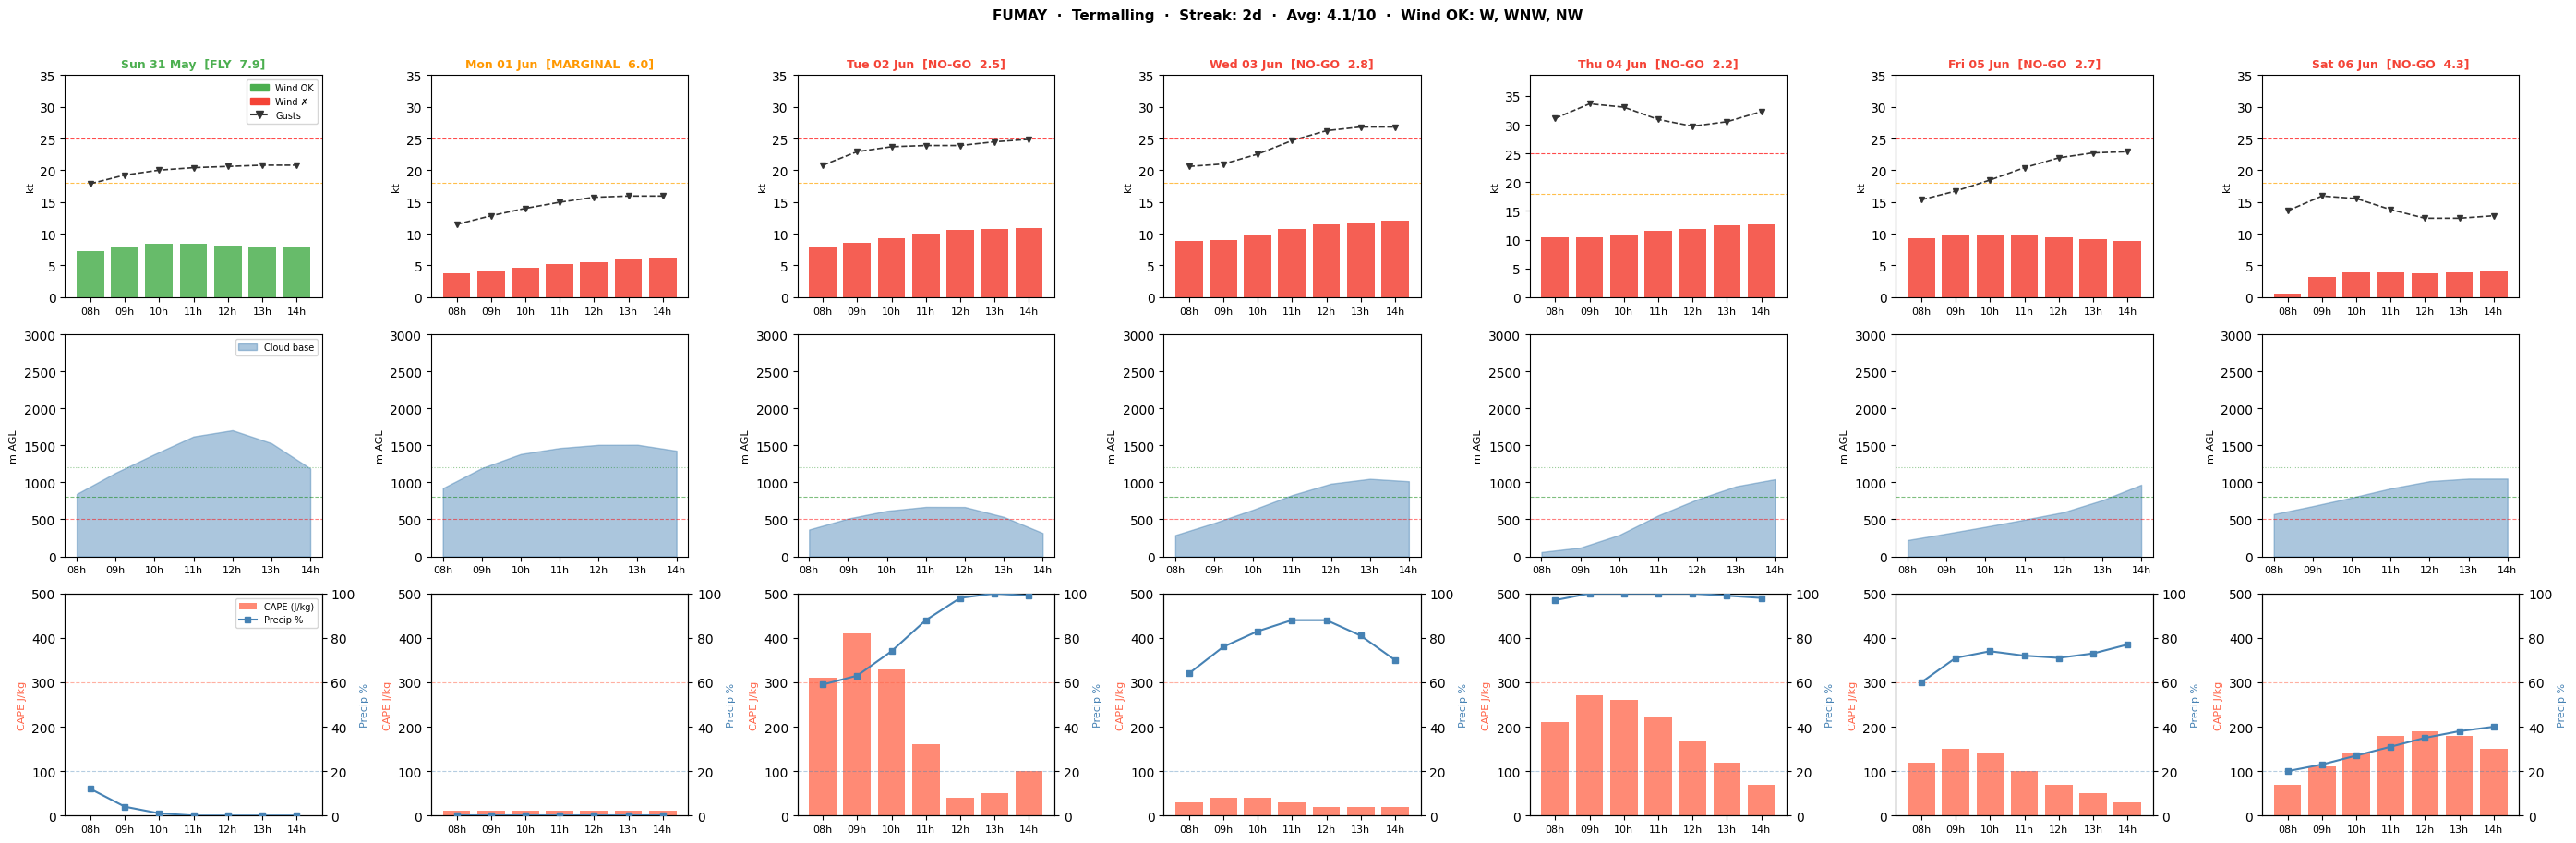

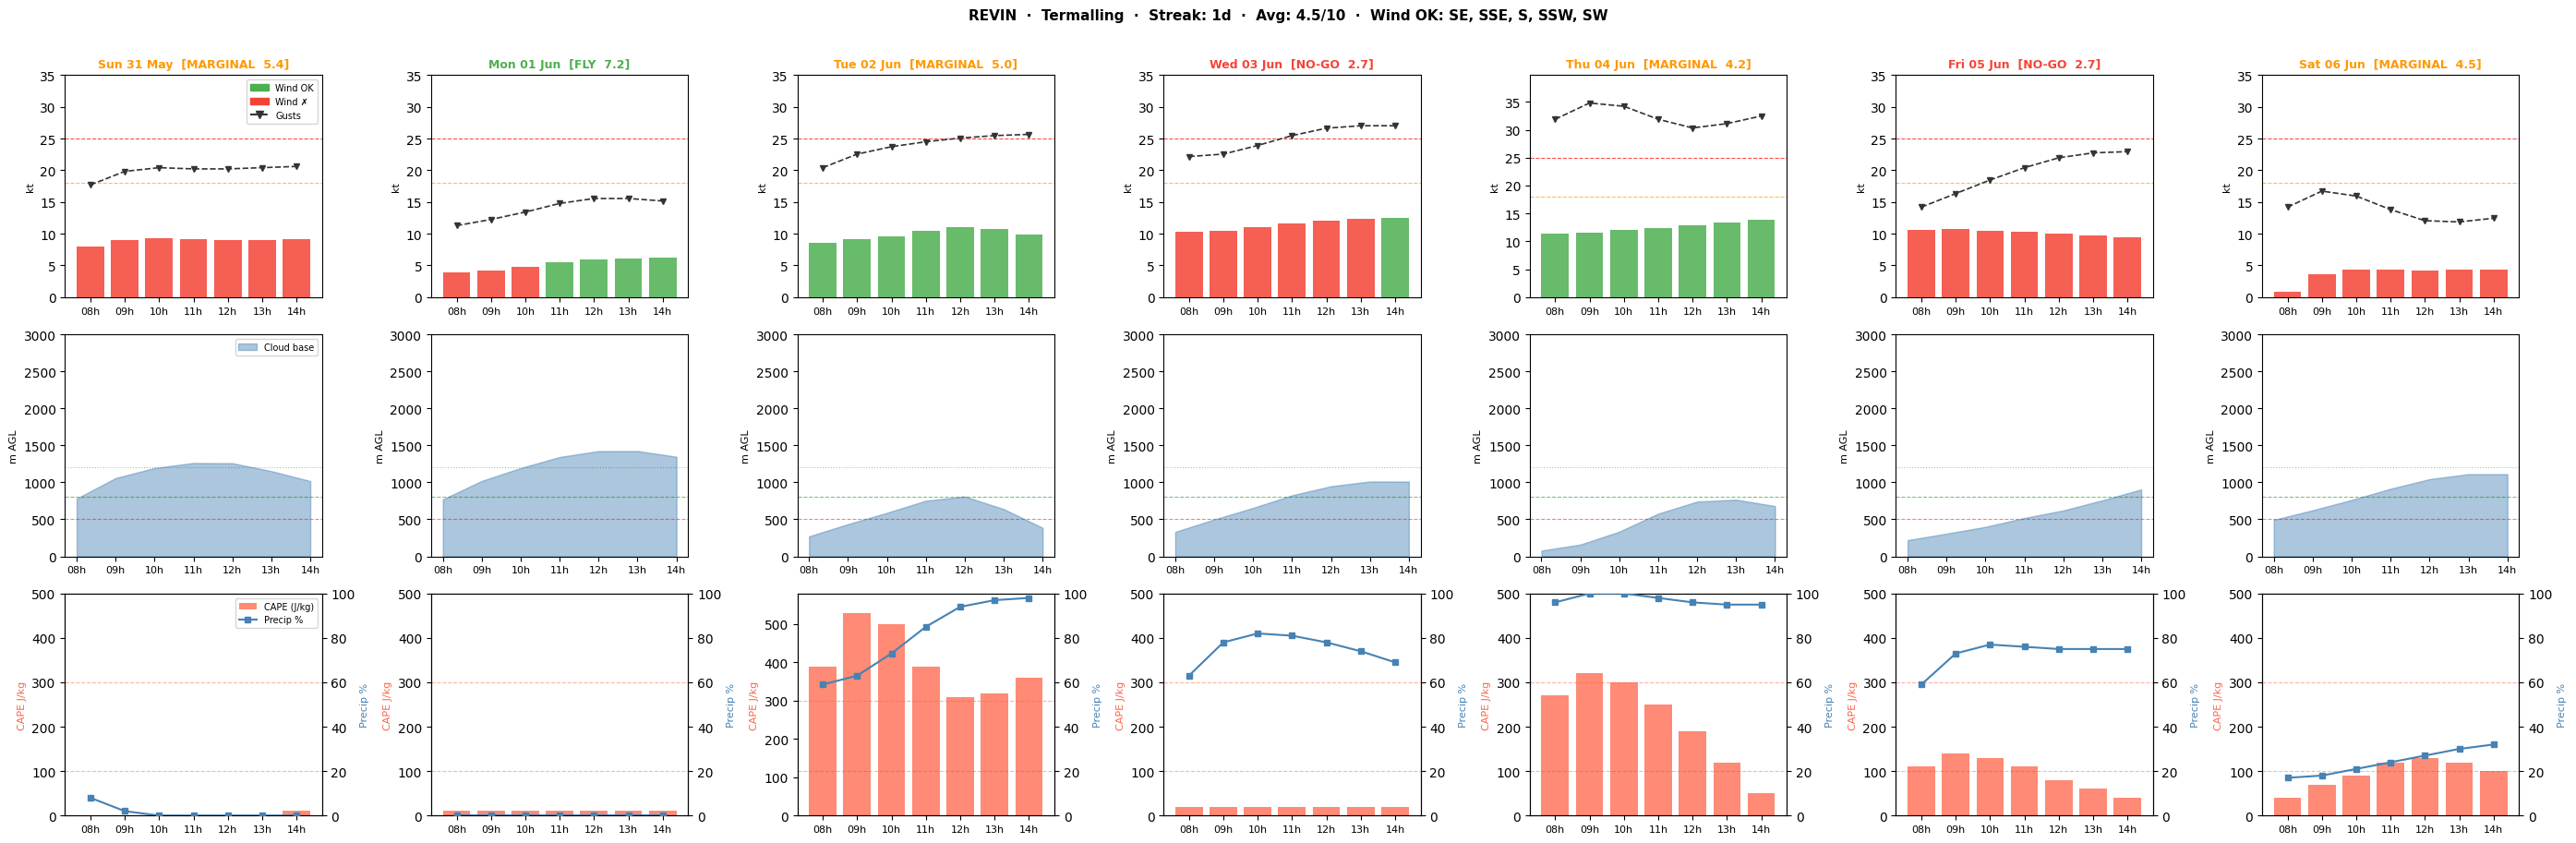

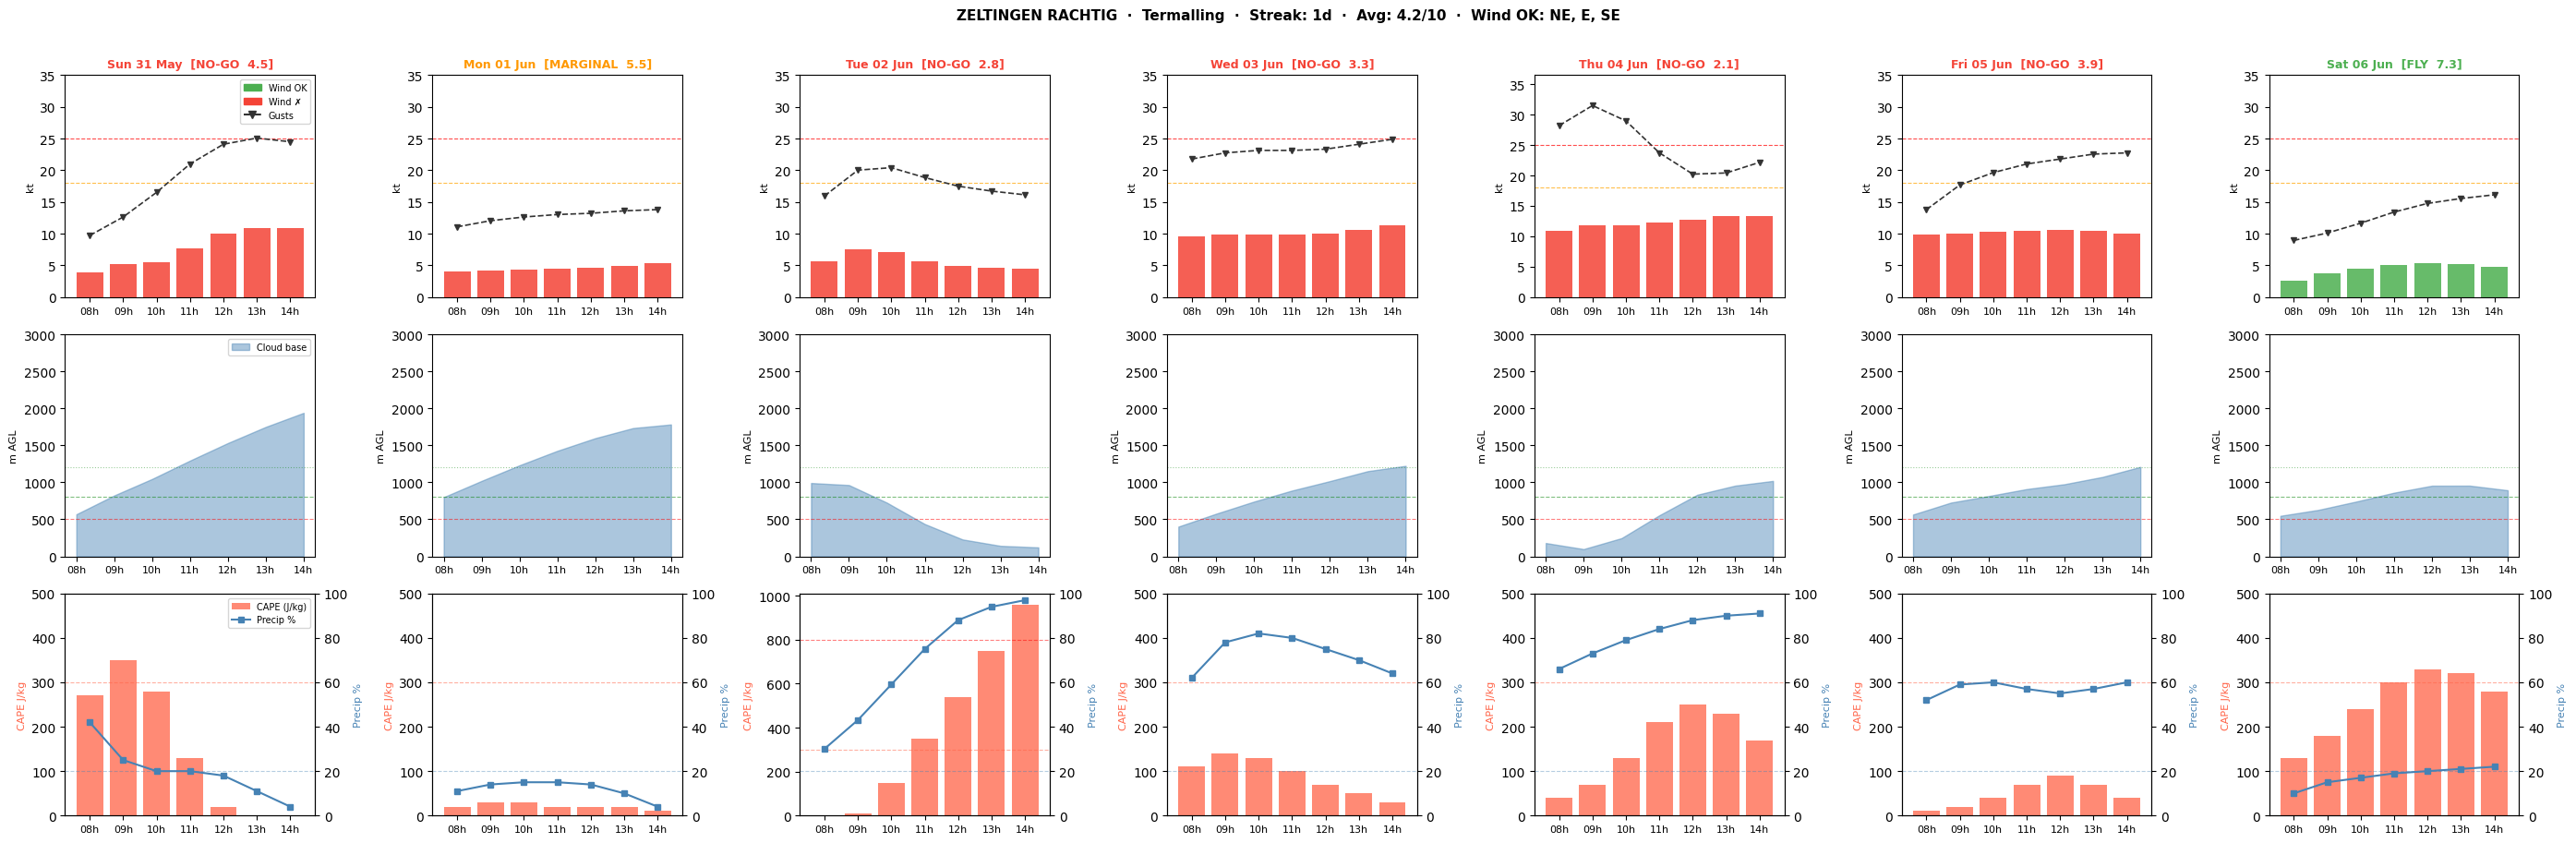

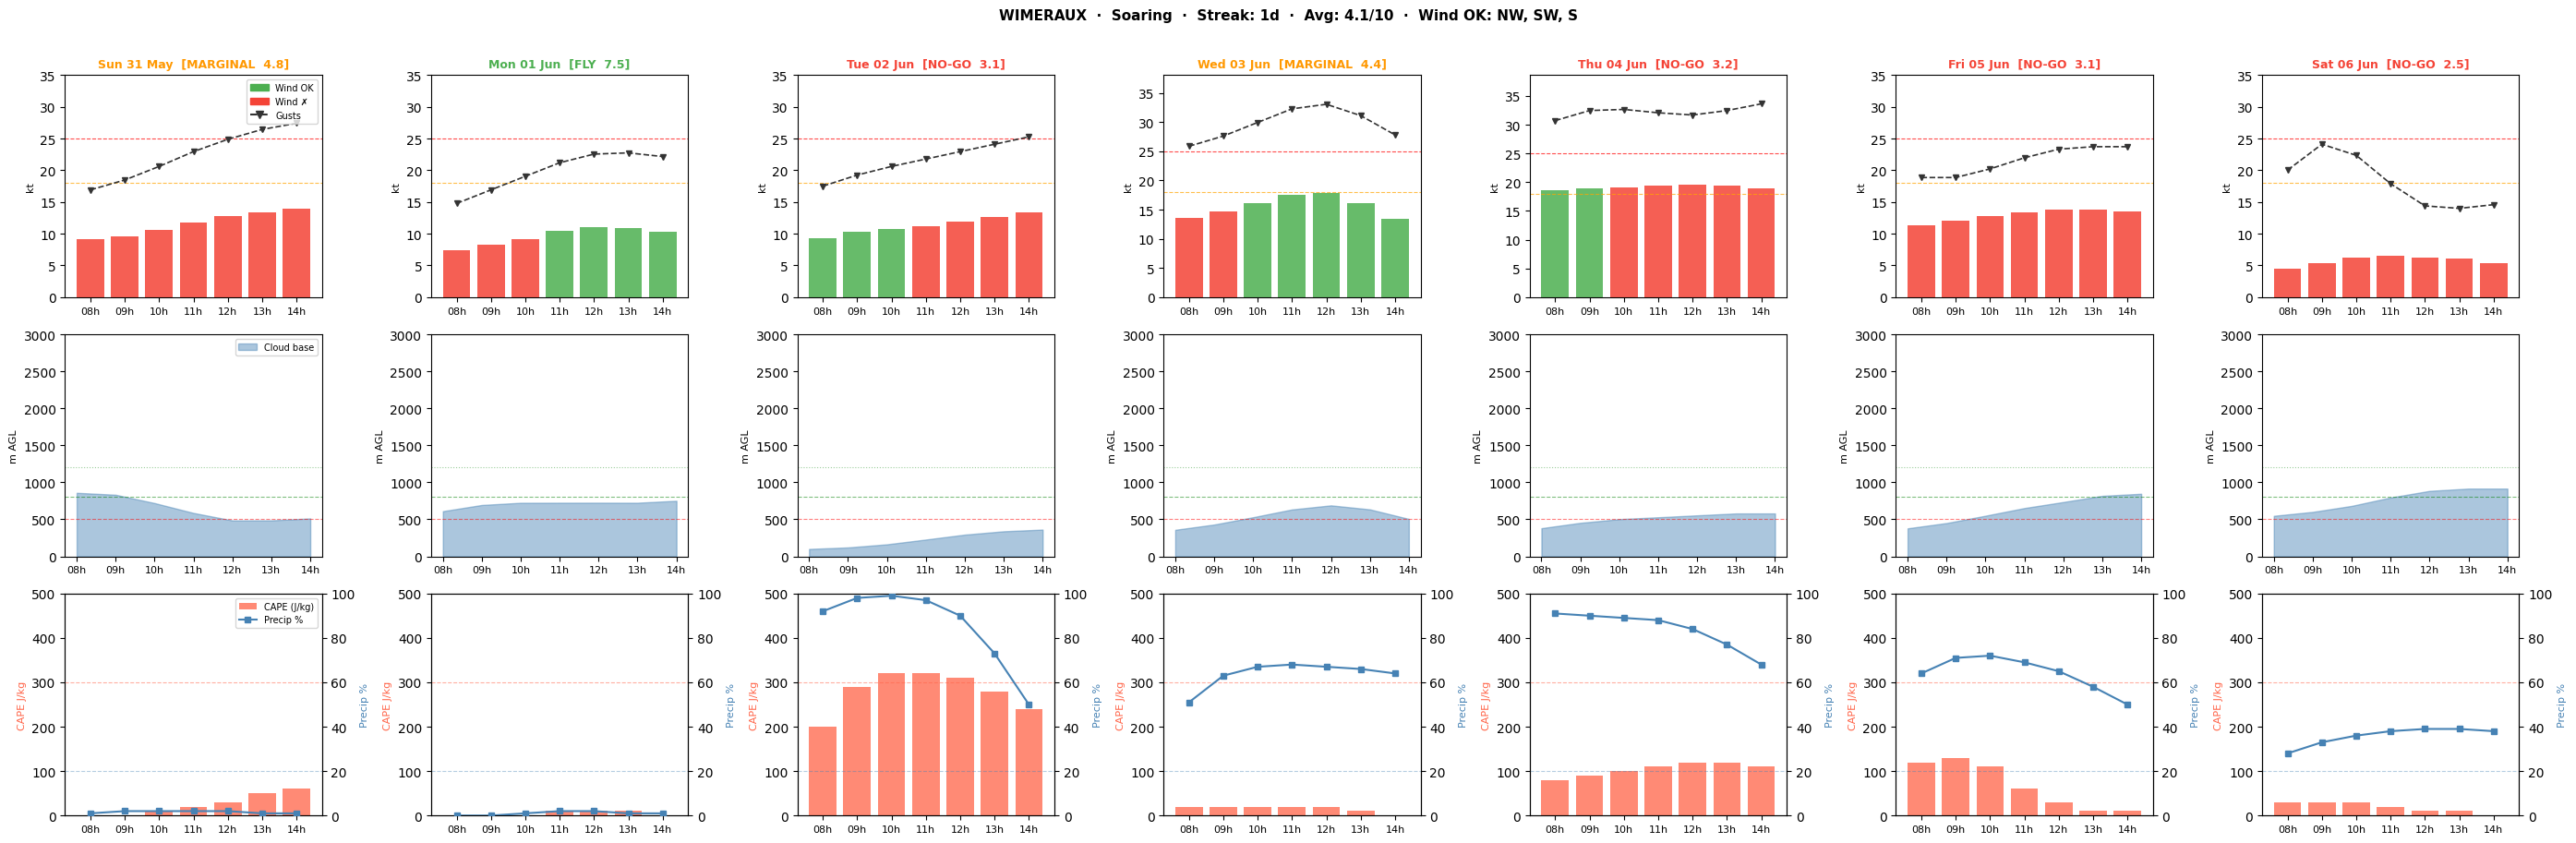

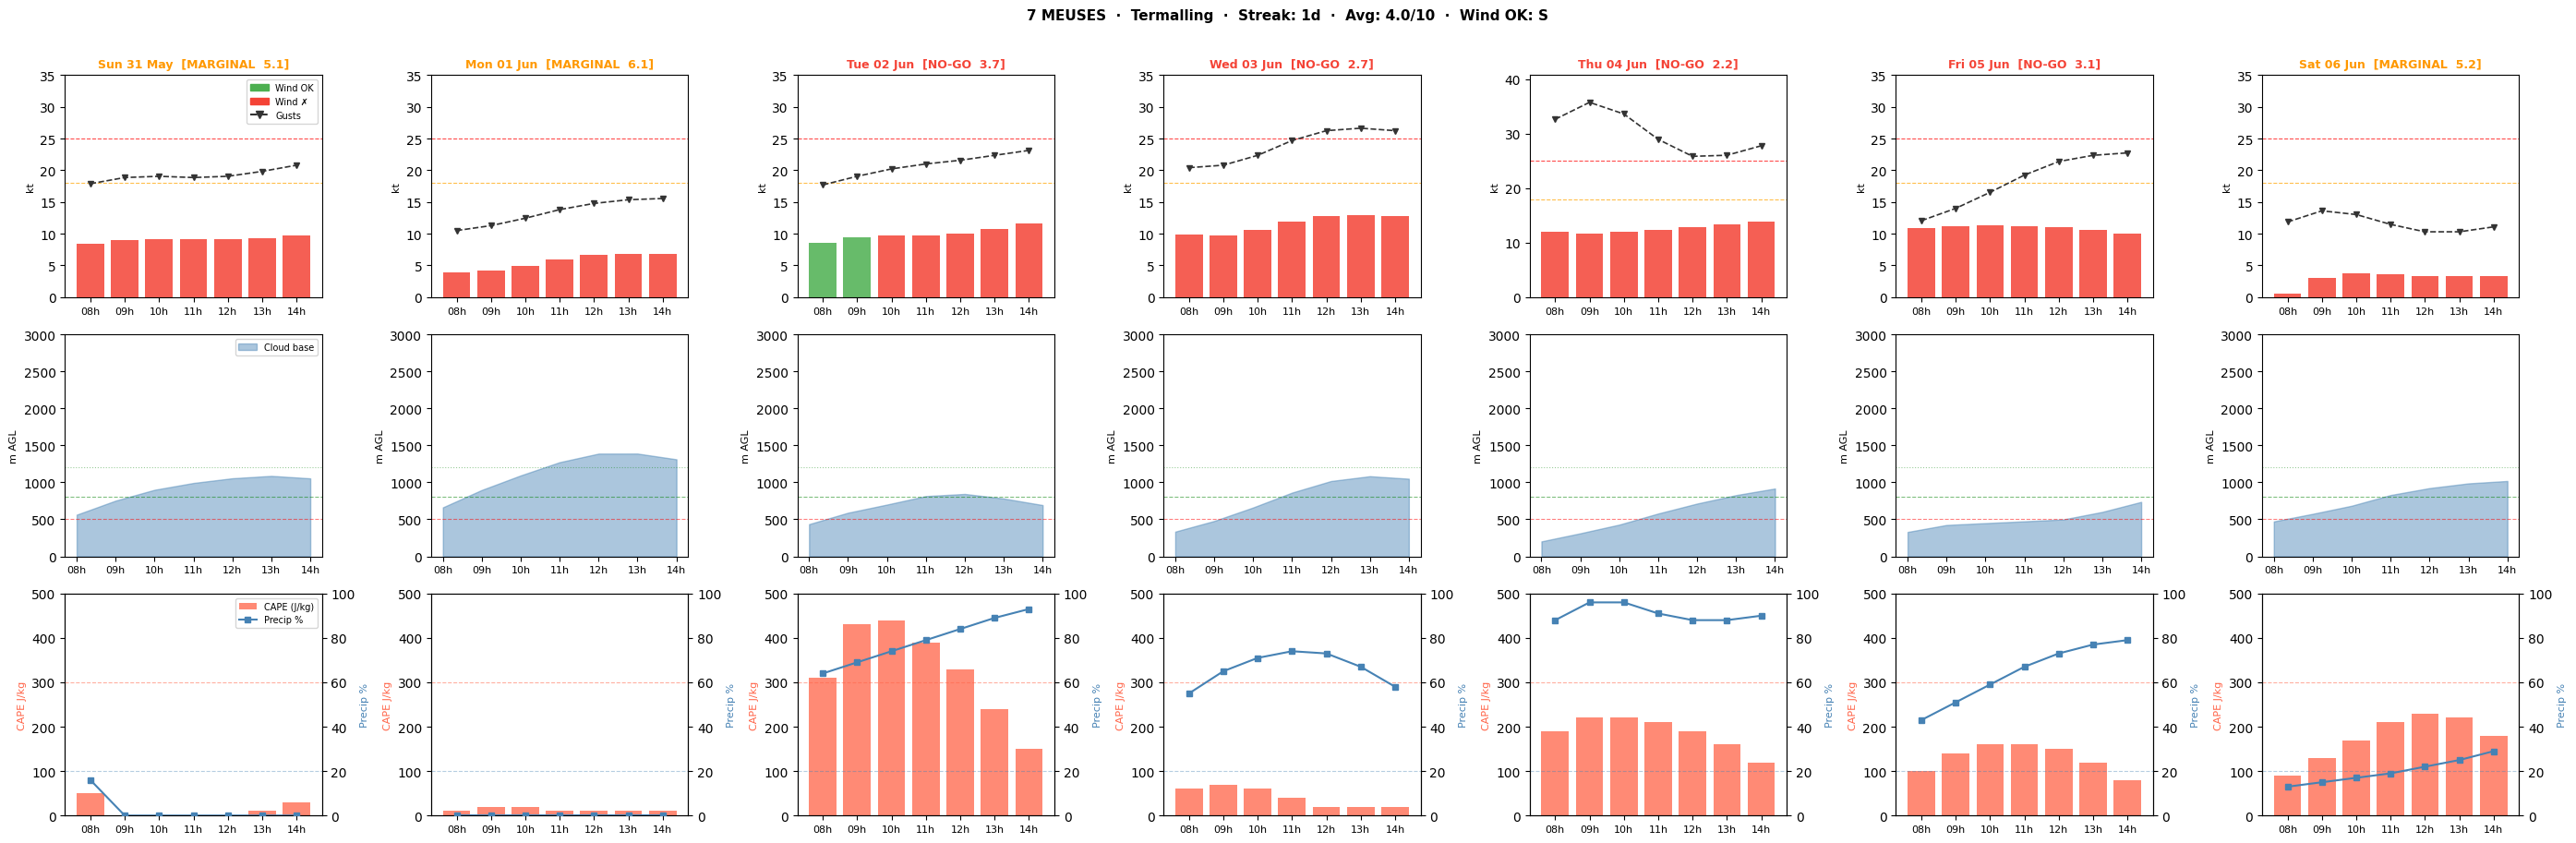

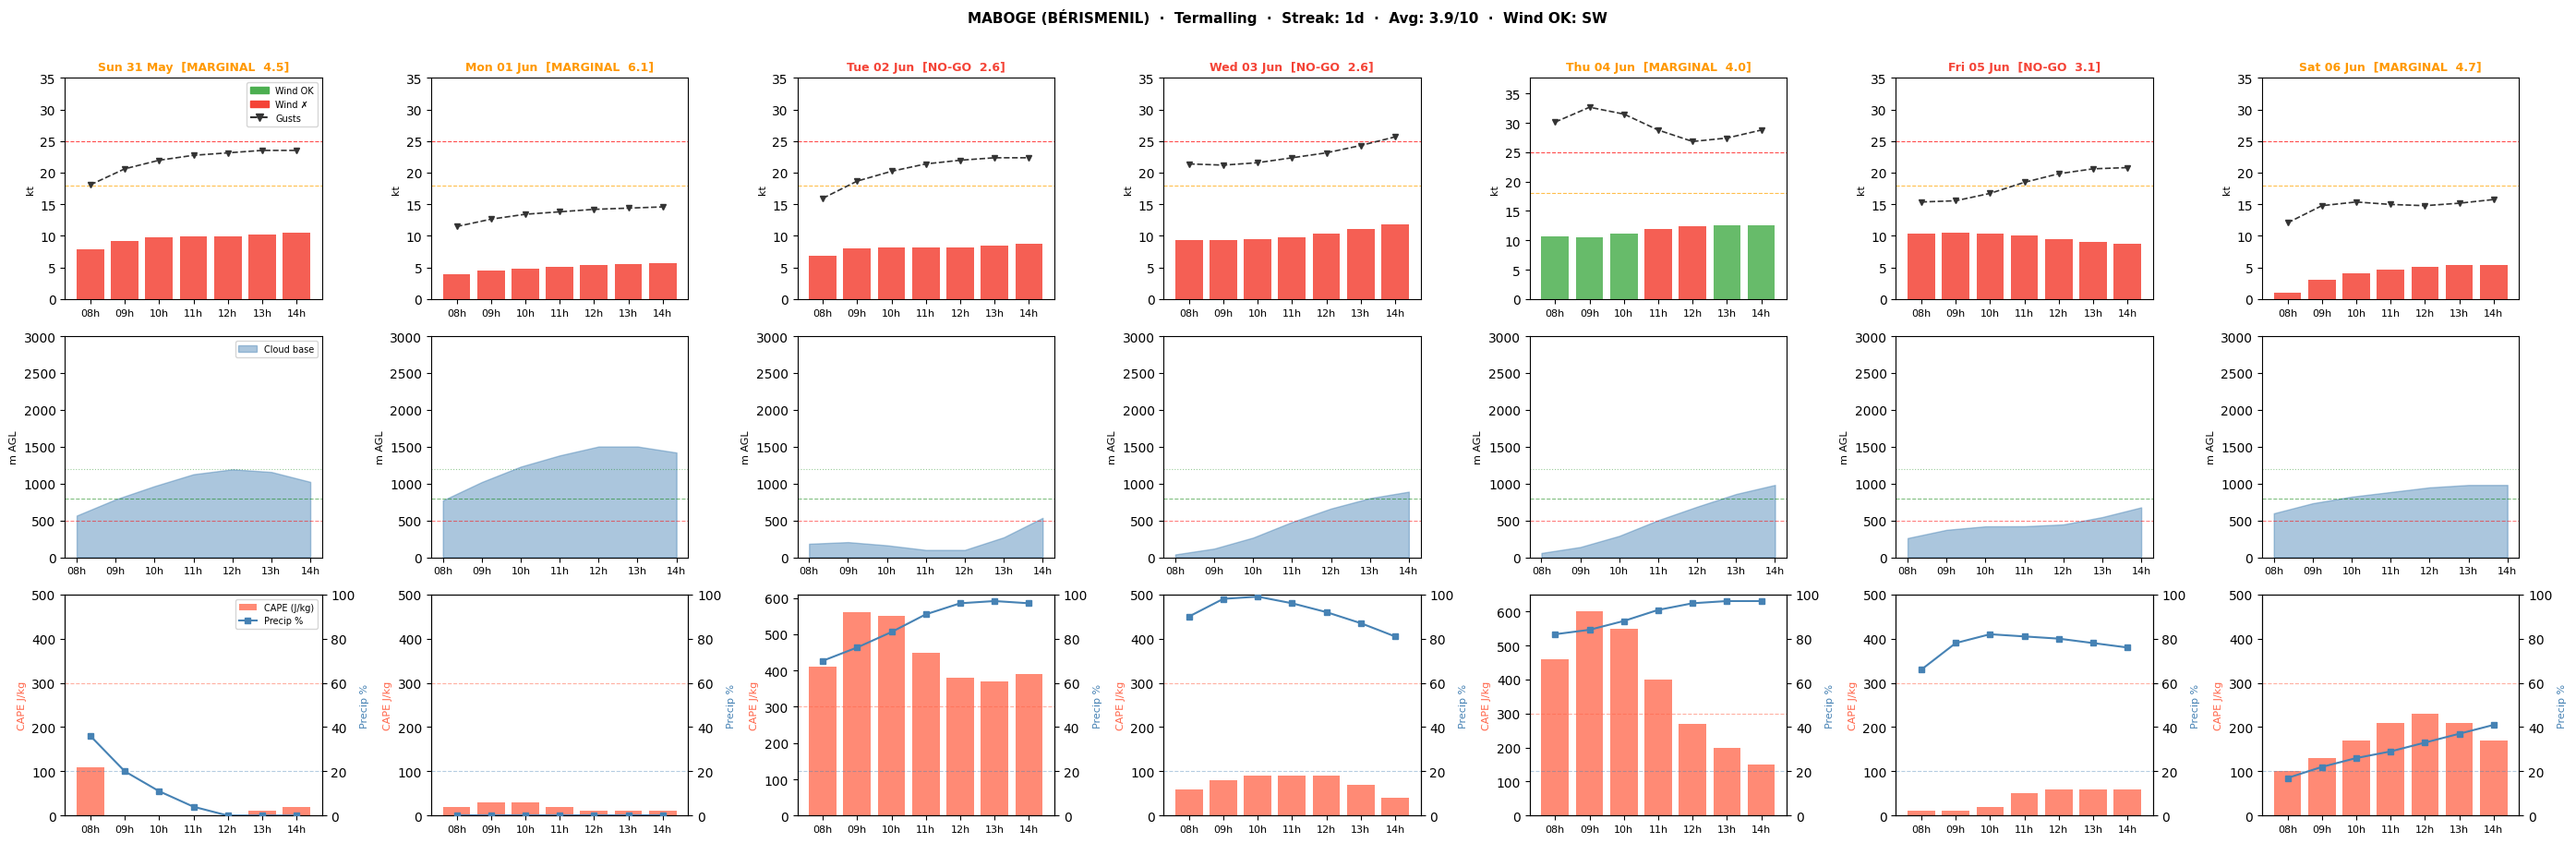

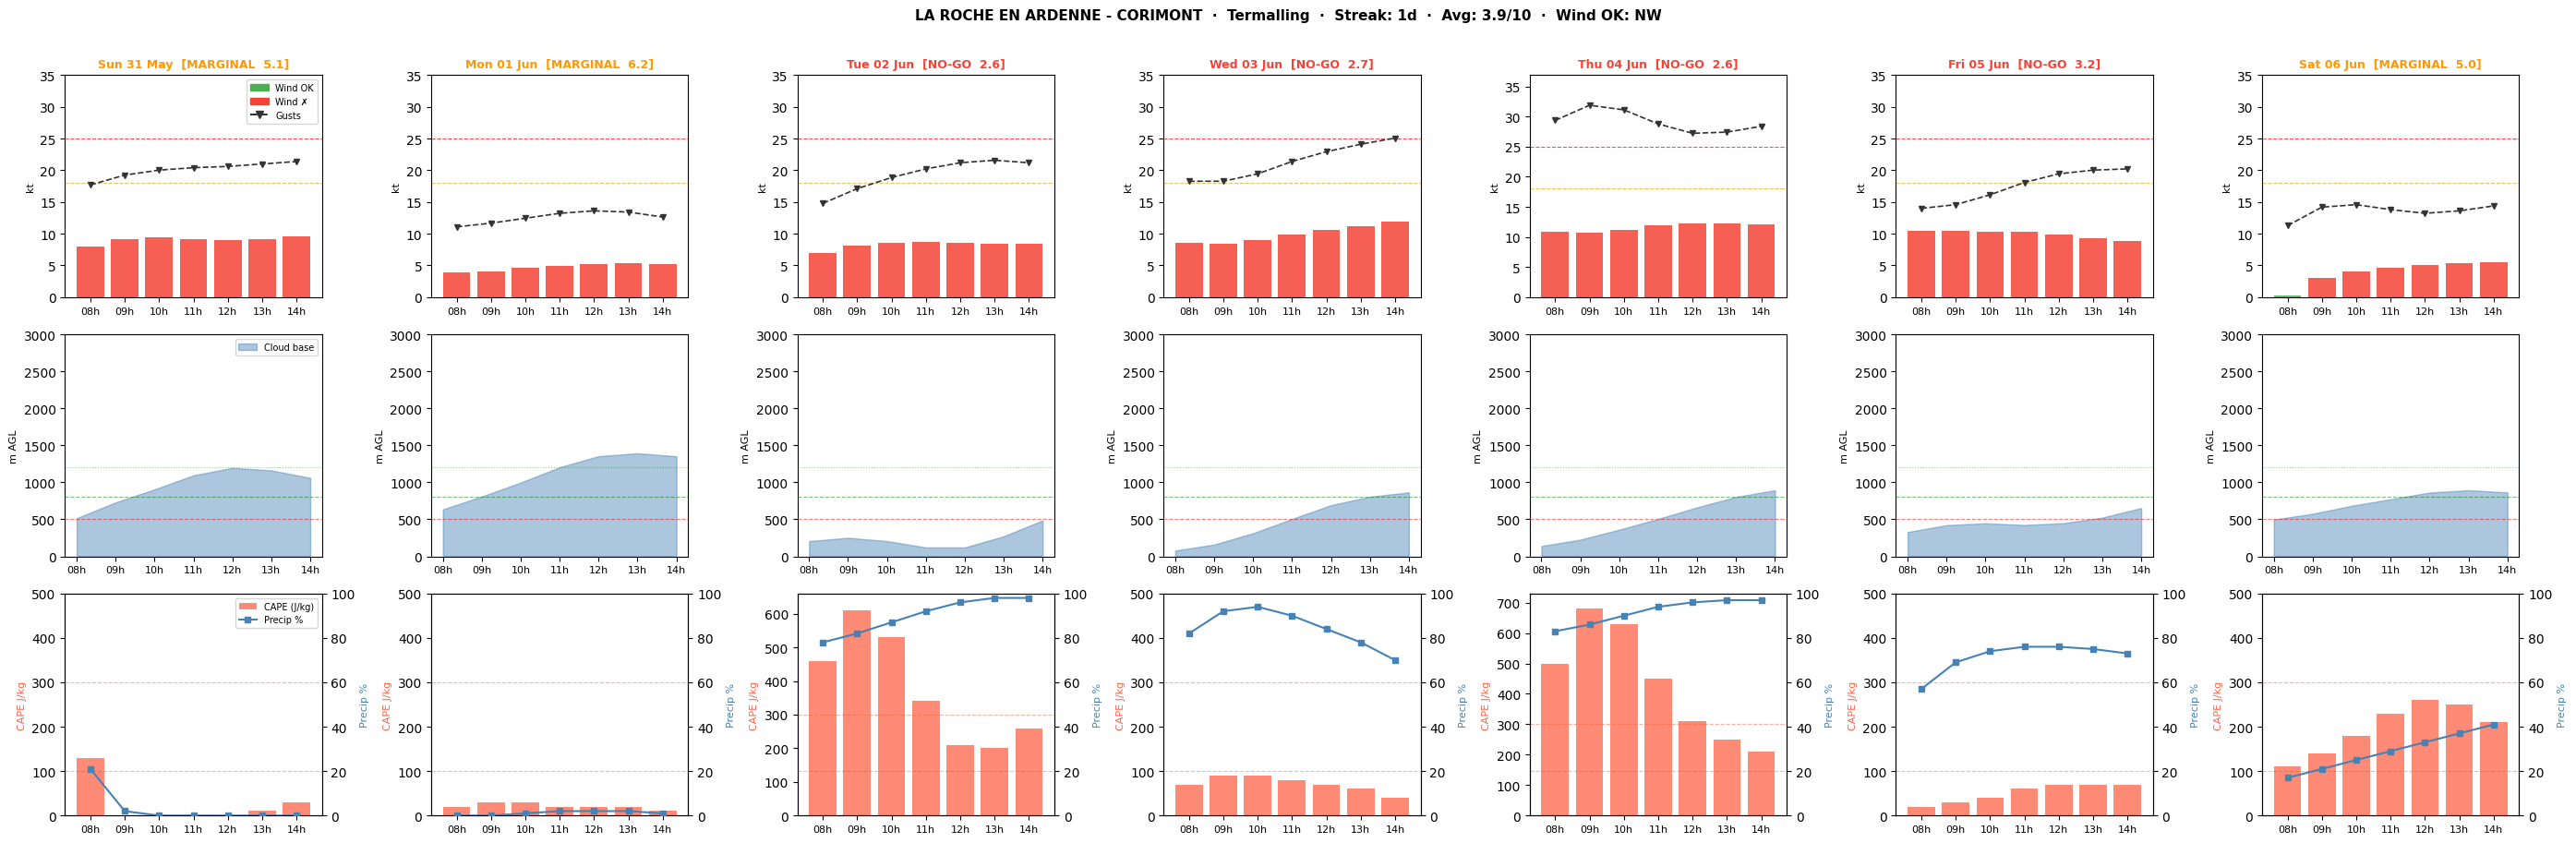

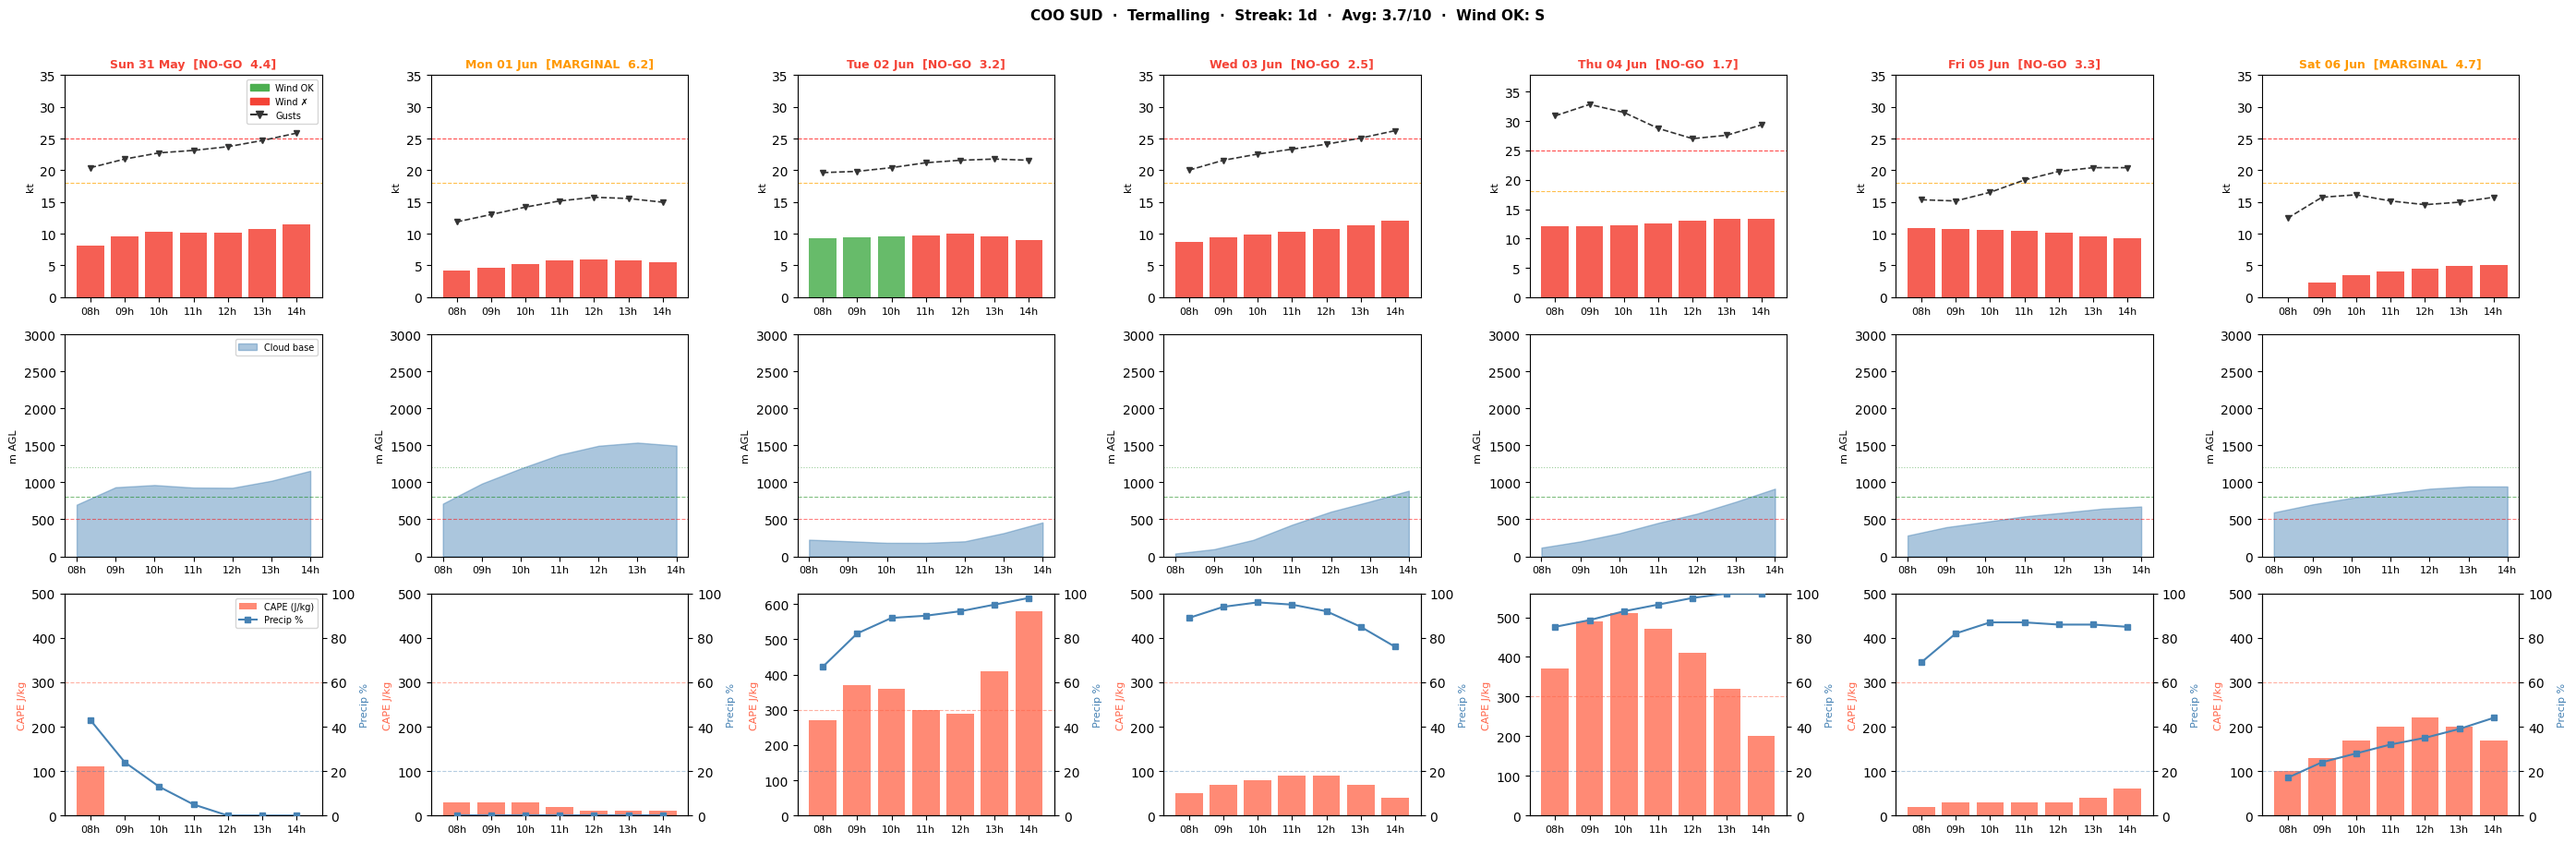

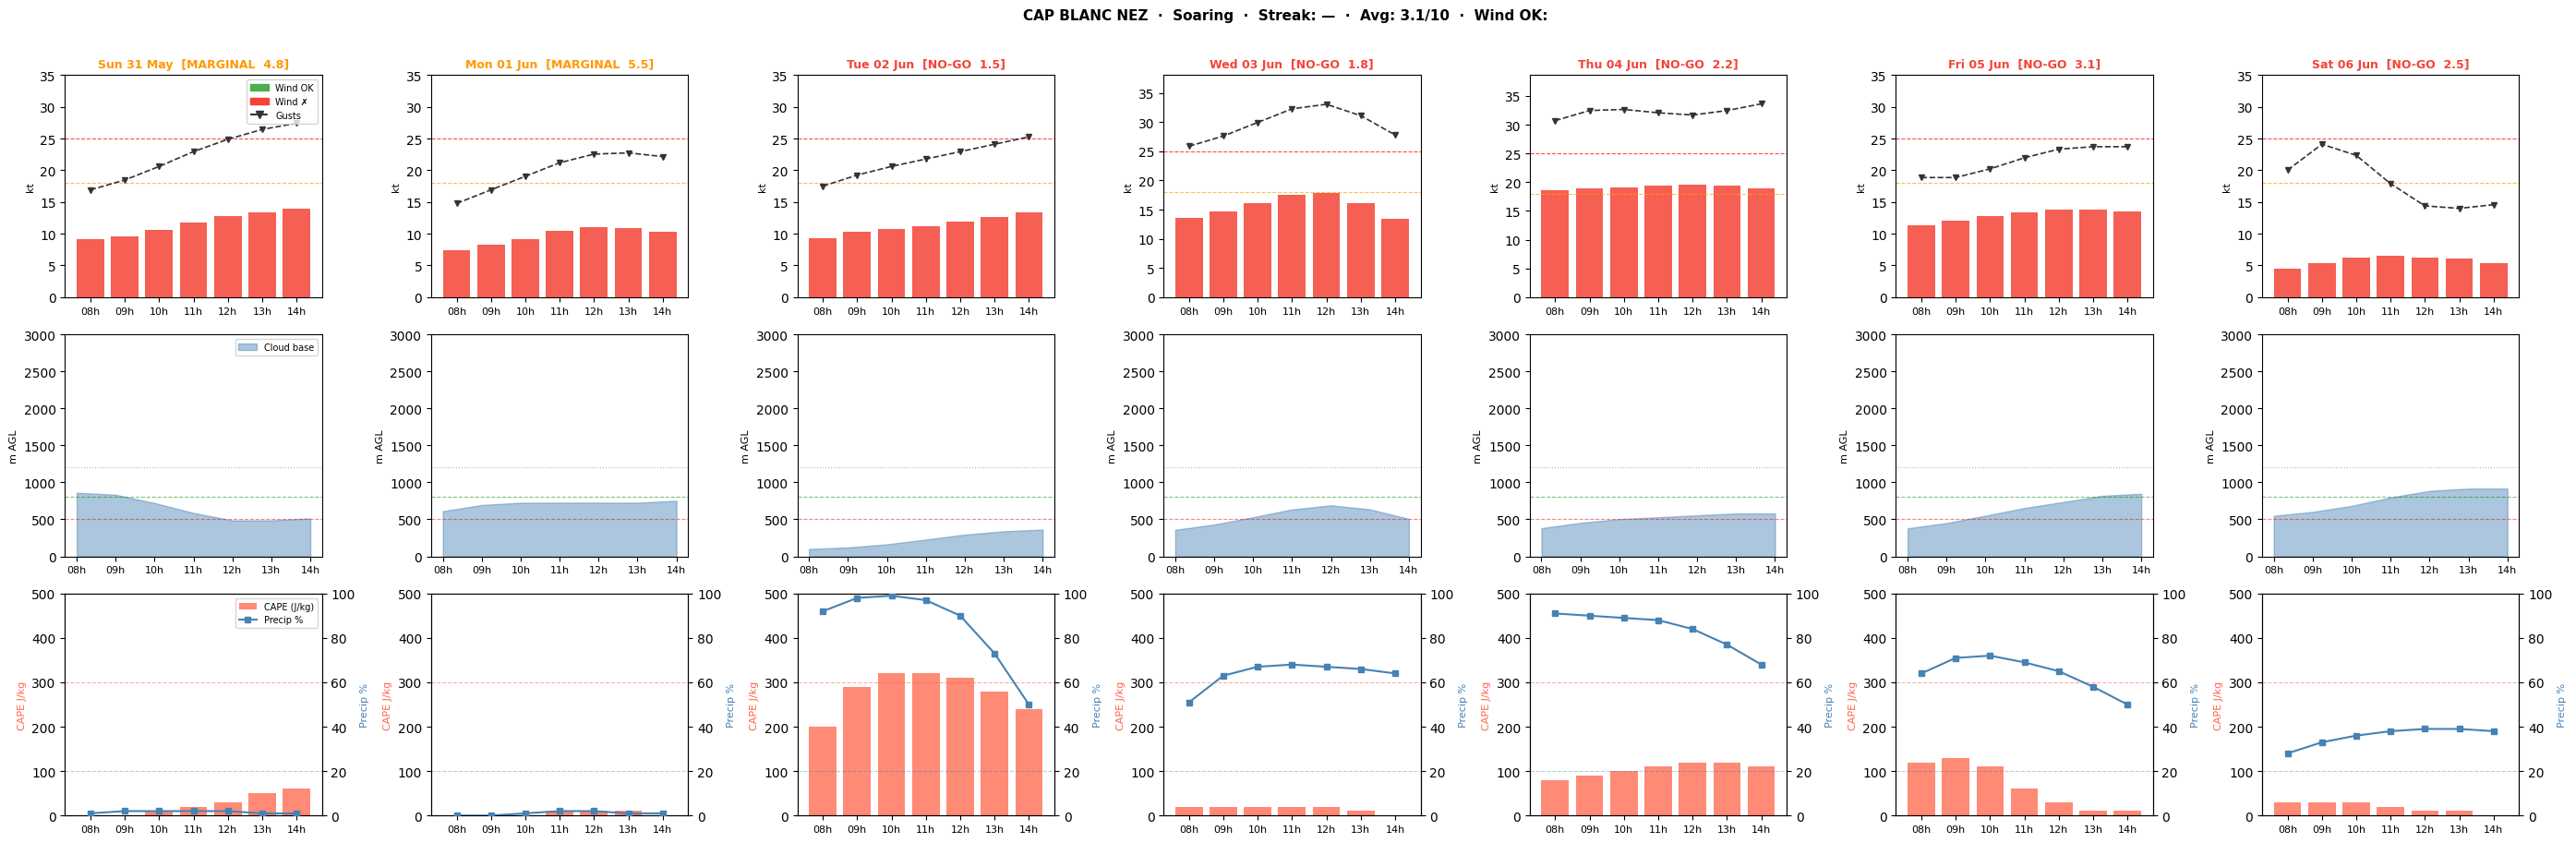

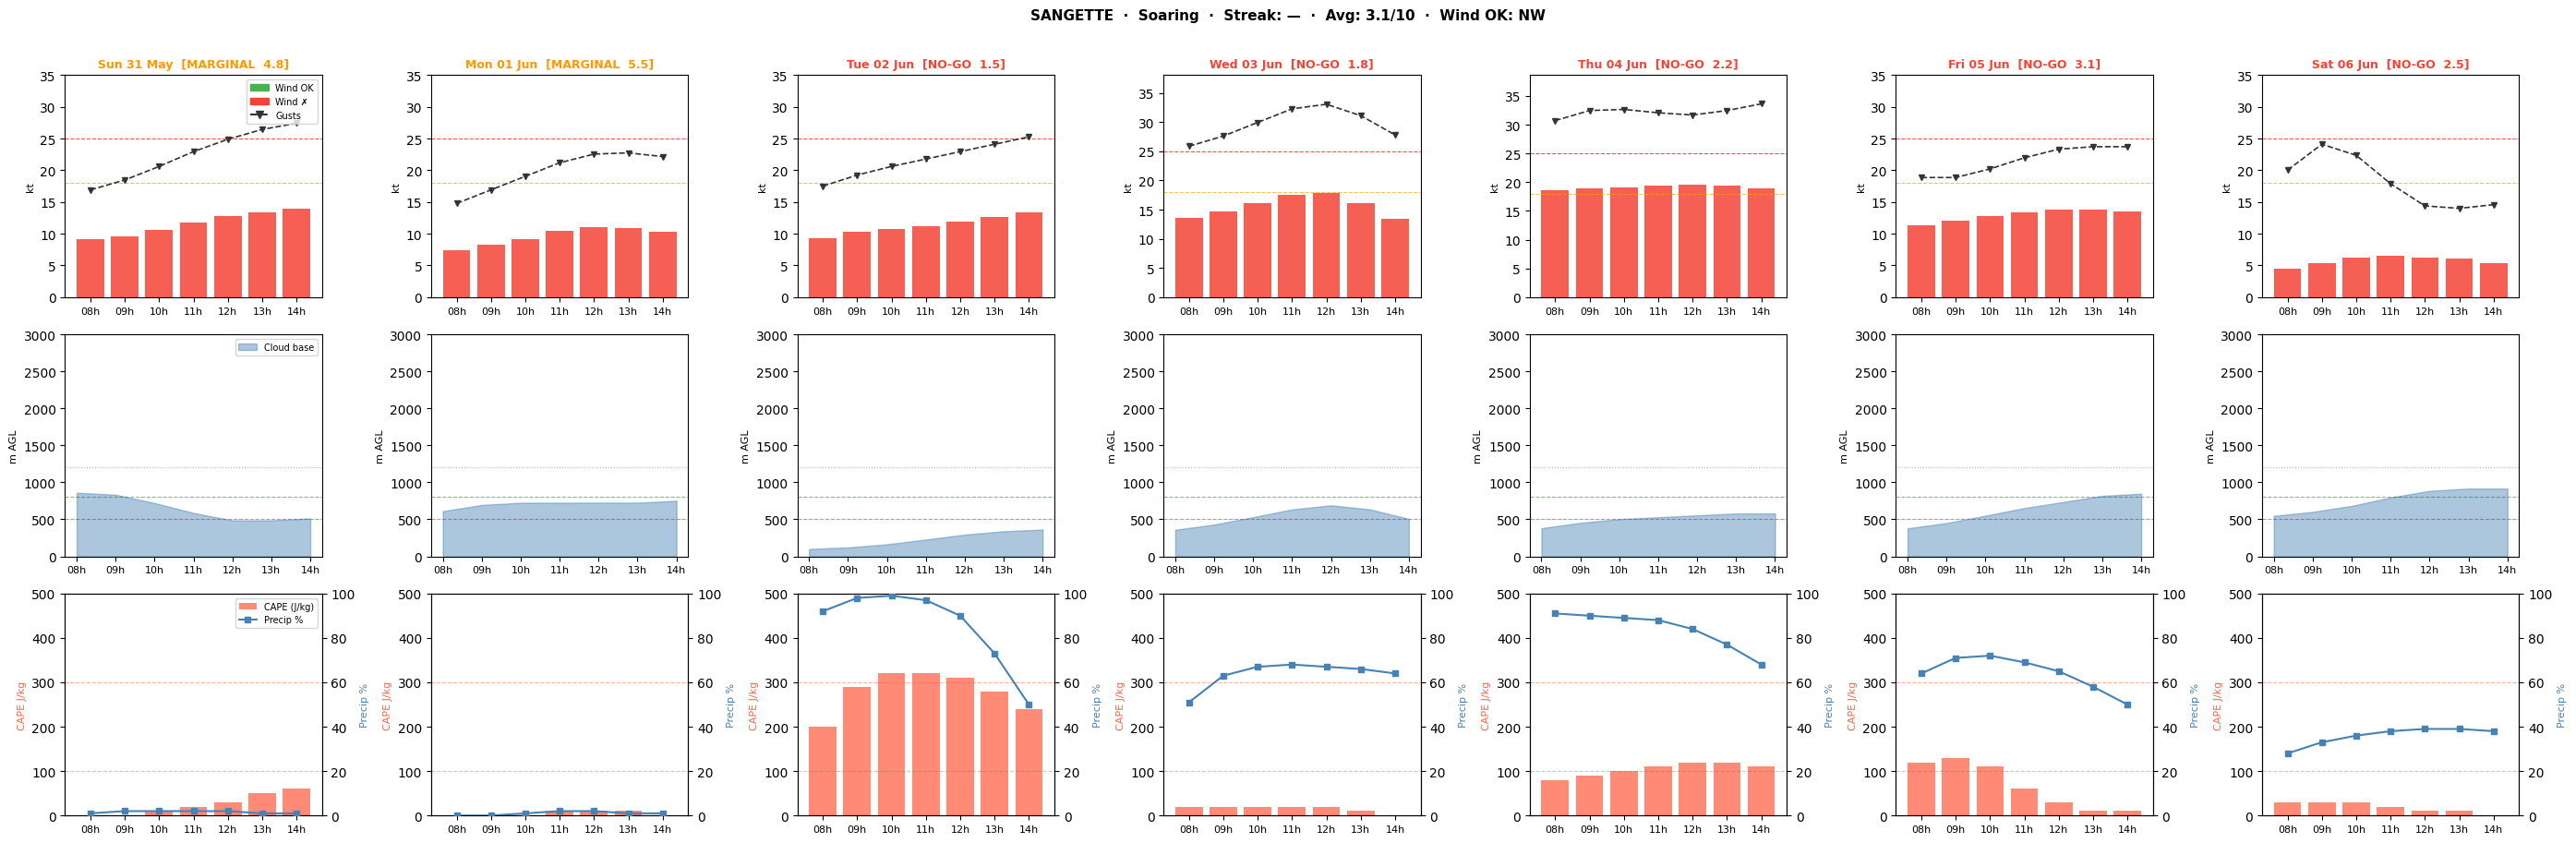

In [20]:
# ── Per-site detail figures ──────────────────────────────────────────────────
_detail_figs: list[tuple[str, plt.Figure]] = []  # kept for HTML export

detail_sites = (
    [r for r in ranked if r["site"]["name"] in SITES_TO_DETAIL]
    if SITES_TO_DETAIL else ranked
)

for r in detail_sites:
    fig = make_detail_figure(r)
    _detail_figs.append((r["site"]["name"], fig))
    plt.show()
    plt.close(fig)


## 🌡️ SkewT Drill-Down

Set `DRILL_SITE` to any site name and `DRILL_DATE` to a specific date (or `None` to auto-select
the best-scoring day). The cell renders a full Skew-T log-P sounding for every flying-window
hour on that day, with temperature, dew point, wind barbs, and standard adiabatic lines.

Auto-selected best day: 2026-06-01  (score=7.2, verdict=fly)


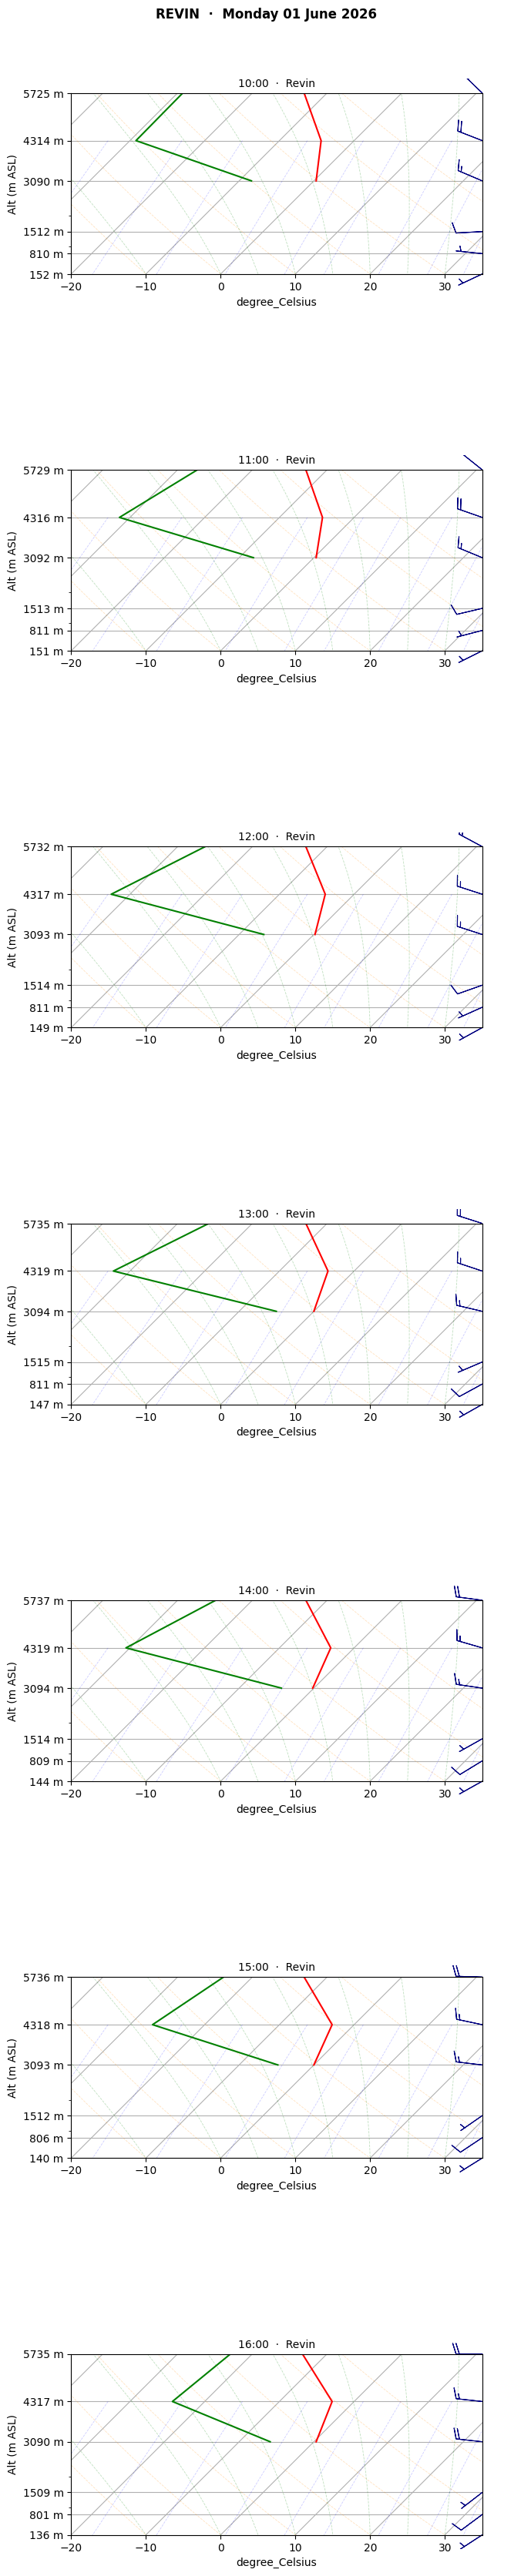

In [21]:
# ── SkewT drill-down config ──────────────────────────────────────────────────
DRILL_SITE = "Revin"   # ← site name (must match sites.json)
DRILL_DATE = None      # ← "YYYY-MM-DD" or None → auto-selects best day

# ── Resolve site + date ───────────────────────────────────────────────────────
drill = next((r for r in ranked if r["site"]["name"] == DRILL_SITE), None)

if drill is None:
    available = [r["site"]["name"] for r in ranked]
    print(f"Site '{DRILL_SITE}' not found.  Available: {available}")
else:
    if DRILL_DATE is None:
        DRILL_DATE = max(
            drill["daily_scores"],
            key=lambda d: drill["daily_scores"][d]["score"],
        )
        ds = drill["daily_scores"][DRILL_DATE]
        print(f"Auto-selected best day: {DRILL_DATE}  "
              f"(score={ds['score']:.1f}, verdict={ds['verdict']})")
    else:
        if DRILL_DATE in drill["daily_scores"]:
            ds = drill["daily_scores"][DRILL_DATE]
            print(f"Plotting {DRILL_DATE}  (score={ds['score']:.1f}, verdict={ds['verdict']})")
        else:
            print(f"Date {DRILL_DATE} not found.  Available: {sorted(drill['daily_scores'])}")
            DRILL_DATE = None

    if DRILL_DATE:
        plot_skewt_for_day(
            drill["hourly_df"],
            drill["site"],
            drill["timezone"],
            DRILL_DATE,
        )


## 💾 Export HTML Report

Generates a self-contained `forecast_report.html` file (all figures embedded as base64 PNG)
that can be opened in any browser and shared without dependencies.

In [ ]:
_HTML_STYLE = """
<style>
  body   { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
           max-width: 1600px; margin: 0 auto; padding: 24px; background: #f0f2f5; color: #222; }
  h1     { font-size: 22px; color: #1a237e; margin-bottom: 4px; }
  .meta  { color: #666; font-size: 13px; margin-bottom: 24px; }
  h2     { font-size: 16px; color: #37474f; border-bottom: 2px solid #cfd8dc;
           padding-bottom: 4px; margin-top: 32px; }
  .card  { background: white; border-radius: 10px; padding: 20px; margin-bottom: 28px;
           box-shadow: 0 2px 8px rgba(0,0,0,.08); }
  img    { max-width: 100%; border-radius: 6px; }
  .legend { font-size: 12px; color: #555; margin-top: 8px; }
  .pill  { display: inline-block; padding: 2px 10px; border-radius: 12px;
           color: white; font-weight: bold; font-size: 12px; margin: 2px; }
</style>
"""

html_parts = [
    "<!DOCTYPE html><html lang='en'><head><meta charset='utf-8'>",
    "<title>Paragliding Forecast</title>",
    _HTML_STYLE,
    "</head><body>",
    f"<h1>🪂 Paragliding Forecast</h1>",
    f"<p class='meta'>Generated {_dt.now().strftime('%A %d %B %Y  %H:%M')} "
    f"· Models: {', '.join(MODELS)} (ensemble) "
    f"· {len(ranked)} site(s) · {len(dates_all)} forecast day(s)</p>",

    # ── Legend ────────────────────────────────────────────────────────────
    "<div>",
    "<span class='pill' style='background:#4caf50'>🟢 FLY ≥ 7.0</span>",
    "<span class='pill' style='background:#ff9800'>🟡 MARGINAL 4.5–7.0</span>",
    "<span class='pill' style='background:#f44336'>🔴 NO-GO &lt; 4.5</span>",
    "</div>",

    # ── Ranking table ─────────────────────────────────────────────────────
    "<h2>📊 Site Ranking</h2>",
    "<div class='card'>",
    _build_ranking_html(ranked, dates_all),
    "</div>",

    # ── Per-site detail figures ───────────────────────────────────────────
    "<h2>📈 Site Details</h2>",
]

for r in detail_sites:
    fig = make_detail_figure(r)
    b64 = fig_to_b64(fig)
    plt.close(fig)
    site = r["site"]
    html_parts += [
        "<div class='card'>",
        f"<h3>{site['name'].title()} — {site.get('type','').title()}"
        f" &nbsp;·&nbsp; Streak: {r['streak_len']}d"
        f" &nbsp;·&nbsp; Avg: {r['avg_score']:.1f}/10</h3>",
        f"<img src='data:image/png;base64,{b64}' alt='{site['name']} detail'>",
        "</div>",
    ]

html_parts.append("</body></html>")

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
report_date = _dt.now().strftime("%Y-%m-%d")
out_path    = reports_dir / f"forecast_report_{report_date}.html"
out_path.write_text("\n".join(html_parts), encoding="utf-8")
print(f"Report saved → {out_path}  ({out_path.stat().st_size // 1024} KB)")

from IPython.display import FileLink
display(FileLink(str(out_path)))


Report saved → reports/forecast_report_2026-05-31.html  (2206 KB)


/home/gajus/ws/src/paraprompt/reports/forecast_report_2026-05-31.html